# Task 4: Environmental Impact Analysis & Optimization Model

## Objective
Analyze the Earth's environmental impact of the 100,000-person Moon Colony transportation systems and develop an optimization model to minimize this impact.

---

## 1. Problem Framework

### 1.1 Scenario Definitions

| Scenario | Transport Mode | Key Emissions | Failure Considerations |
|:---------|:---------------|:--------------|:-----------------------|
| **A (Elevator)** | Pure Space Elevator | Grid electricity ($CO_2$) | Downtime → Emergency rockets |
| **B (Rocket)** | Pure Rocket | $CO_2$, Black Carbon, $NO_x$ | Mission failure → Replacement launch |
| **C (Hybrid)** | Elevator + Rockets | Combined emissions | Both failure modes |

### 1.2 Environmental Impact Metrics (CO₂-equivalent)

**Rocket Emissions per Launch** (Starship-class, methane fuel):
- $CO_2$ emissions: $\sim 2,683$ tons per launch (complete combustion of $\sim 1,200$ tons $CH_4$)
- Black Carbon (soot): $\sim 0.5$ tons per launch → Stratospheric warming multiplier: $\times 500$ ($CO_2e$)
- $NO_x$ emissions: $\sim 15$ tons per launch → Ozone depletion multiplier: $\times 298$ ($CO_2e$)

**Elevator Emissions** (Earth-side grid electricity):
- Power consumption: $\sim 50$ MWh per 125-ton climber trip
- Grid carbon intensity: $\sim 0.4$ kg $CO_2$/kWh (global average, improving to $\sim 0.2$ by 2050)

### 1.3 Core Formulas

**Total Environmental Impact (TEI)**:
$$TEI = \sum_{i} \left( E_{ops,i} + E_{fail,i} \right)$$

**Operational Emissions** ($E_{ops}$):
$$E_{ops} = \alpha \cdot E_{elevator} + (1-\alpha) \cdot E_{rocket}$$

**Failure-Induced Emissions** ($E_{fail}$):
$$E_{fail,rocket} = \frac{p}{1-p} \cdot E_{rocket} \quad \text{(replacement launches)}$$
$$E_{fail,elevator} = D \cdot \lambda_{down} \cdot E_{rocket,backup} \quad \text{(downtime coverage)}$$

Where:
- $\alpha$: Fraction of cargo via elevator ($0 \leq \alpha \leq 1$)
- $p$: Rocket failure rate per launch
- $\lambda_{down}$: Elevator downtime rate (days/year)
- $D$: Daily supply requirement (tons/day)

In [74]:
# ===================================================================
# IMPORTS AND CONFIGURATION
# ===================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, minimize_scalar
from scipy.stats import norm
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# ===================================================================
# MCM STYLE CONFIGURATION
# ===================================================================
MCM_BLUE = '#1E5AA8'
MCM_TEAL = '#2E9090'
MCM_SAGE = '#4CAF50'
MCM_LAVENDER = '#7B68B4'
MCM_CORAL = '#E85A5A'
MCM_ORANGE = '#FF9800'
MCM_GRAY = '#5D6470'
MCM_LIGHT = '#90CAF9'
MCM_SILVER = '#B0BEC5'

MCM_COLORS = [MCM_BLUE, MCM_TEAL, MCM_SAGE, MCM_LAVENDER, MCM_CORAL, MCM_ORANGE]

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Palatino', 'Times New Roman'],
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# ===================================================================
# CORE PARAMETERS FROM PREVIOUS TASKS
# ===================================================================

# Task 1 Parameters
TARGET_MASS_TONS = 100_000_000      # 100 Million tons total
DEPLOYMENT_YEARS = 20                # Timeline constraint
DAILY_SUPPLY_TONS = 1241.6          # Task 3: Water security requirement (tons/day)
ANNUAL_SUPPLY_TONS = DAILY_SUPPLY_TONS * 365  # ~453,184 tons/year

# Rocket Parameters (Starship-class)
PAYLOAD_PER_LAUNCH = 125            # tons/launch
ROCKET_FAILURE_RATE = 0.01          # 1% per launch (Task 2 baseline)
COST_PER_KG_ROCKET_2050 = 114.7     # $/kg in 2050 (Task 1)

# Space Elevator Parameters (Consistent with Task 2)
SE_CAPACITY_PER_HARBOUR = 179_000   # tons/year per harbour
NUM_HARBOURS = 3
SE_TOTAL_CAPACITY = SE_CAPACITY_PER_HARBOUR * NUM_HARBOURS  # 537,000 tons/year
SE_CAPACITY_TONS_YEAR = SE_TOTAL_CAPACITY  # Alias for compatibility
SE_CAPEX = 17e9                     # $17 Billion construction
SE_OPEX_RATE = 0.05                 # 5% annual
SE_VAR_COST_PER_KG = 12.0           # $/kg variable cost

# Elevator Reliability (Consistent with Task 2)
# Minor failure model: A = 1 / (1 + λ_op × MTTR_op)
# Based on ISS mechanical systems: λ_op = 1.5e-5/hr, MTTR = 48 hr
SE_MINOR_FAILURE_RATE = 1.5e-5      # per hour (λ_op from Task 2)
SE_MTTR_MINOR_HOURS = 48            # hours (MTTR_op from Task 2)
ELEVATOR_AVAILABILITY = 1 / (1 + SE_MINOR_FAILURE_RATE * SE_MTTR_MINOR_HOURS)  # ≈ 99.93%

# Catastrophic failure parameters (from Task 2)
LAMBDA_CAT = 0.0048                 # catastrophic failures per year
MTTR_CAT_YEARS = 2                  # mean time to repair major failures

# Compatibility aliases for ImpactSimulator (legacy interface)
# These convert the hourly failure rate to an equivalent daily model
# Expected downtime per year = λ_op × MTTR_op × (365×24) = 1.5e-5 × 48 × 8760 ≈ 6.3 hours/year
# Convert to daily model: daily_rate × mttr_days × 365 = 6.3 hours → very low
ELEVATOR_DOWNTIME_RATE = SE_MINOR_FAILURE_RATE * 24  # Convert per-hour to per-day (≈ 0.00036/day)
ELEVATOR_MTTR_DAYS = SE_MTTR_MINOR_HOURS / 24        # Convert hours to days (= 2 days)

# Task 1 Baseline Cost (from Task 1 optimal scenario)
TASK1_BASELINE_COST = 320e9         # $320 Billion (approximate from Task 1)

# ───────────────────────────────────────────────────────────────────────────
# Task 2 Optimal Solution → Scenario C Mapping
# ───────────────────────────────────────────────────────────────────────────
# Task 2 optimal: 100% elevator utilization + 25% rocket utilization
# - Elevator capacity: 537,000 tons/year × 100% = 537,000 tons/year
# - Rocket capacity: 7,300 launches × 125 tons × 25% = 228,125 tons/year  
# - Total throughput: 765,125 tons/year
# - α (elevator mass fraction) = 537,000 / 765,125 ≈ 70.2%
TASK2_OPTIMAL_ALPHA = 0.702         # Corresponds to Task 2 Pareto optimal solution

print("="*70)
print("Task 4: Environmental Impact Analysis for Moon Colony Transport")
print("="*70)
print(f"Target Mass:          {TARGET_MASS_TONS/1e6:.0f} Million tons")
print(f"Daily Supply Need:    {DAILY_SUPPLY_TONS:,.1f} tons/day")
print(f"Annual Supply Need:   {ANNUAL_SUPPLY_TONS:,.0f} tons/year")
print(f"Rocket Failure Rate:  {ROCKET_FAILURE_RATE*100:.1f}%")
print(f"Elevator Availability: {ELEVATOR_AVAILABILITY*100:.2f}%")
print(f"Deployment Timeline:  {DEPLOYMENT_YEARS} years")
print(f"Task 2 Optimal α:     {TASK2_OPTIMAL_ALPHA*100:.1f}% (100% elev + 25% rocket)")

Task 4: Environmental Impact Analysis for Moon Colony Transport
Target Mass:          100 Million tons
Daily Supply Need:    1,241.6 tons/day
Annual Supply Need:   453,184 tons/year
Rocket Failure Rate:  1.0%
Elevator Availability: 99.93%
Deployment Timeline:  20 years
Task 2 Optimal α:     70.2% (100% elev + 25% rocket)


## 2. Emission Factor Database

### 2.1 Rocket Emission Factors

**Chemical Reaction** (Methane + LOX):
$$CH_4 + 2O_2 \rightarrow CO_2 + 2H_2O$$

**Emission Calculations**:
- Fuel per launch: $\sim 1,200$ tons $CH_4$
- $CO_2$ per ton $CH_4$: $2.75$ tons (molecular weight ratio: $44/16$)
- Black Carbon: $\sim 0.04\%$ of fuel mass (incomplete combustion)
- $NO_x$: $\sim 1.25\%$ of fuel mass (high-temperature oxidation)

### 2.2 Radiative Forcing & GWP Multipliers

**Key Innovation**: Beyond simple $CO_2$ mass, we model **Equivalent Radiative Forcing (ERF)**.

Stratospheric black carbon (BC) has unique climate impacts:
- BC injected at 20-50 km altitude persists for 3-5 years (vs. weeks at ground level)
- Absorption of solar radiation creates localized heating
- Estimated ERF: $\Delta F_{BC} \approx 0.1-0.5 \text{ W/m}^2$ per Tg BC/year

**GWP Conversion** (100-year horizon):

| Emission Type | GWP | ERF Contribution | Notes |
|:--------------|:----|:-----------------|:------|
| $CO_2$ | 1 | Baseline | Long-lived, well-mixed |
| Black Carbon (Stratosphere) | 500-2000 | High (localized) | Short-lived but intense warming |
| $NO_x$ → $O_3$ depletion | 298 | Moderate | Indirect via ozone chemistry |
| Water Vapor (Stratosphere) | ~5 | Low | Minor contribution |

### 2.3 Elevator Emissions (Direct + Indirect)

**Direct Emissions** (Electricity):
- Grid carbon intensity: 0.20 kg $CO_2$/kWh (2050 projection)
- Power per climber: ~50 MWh

**Indirect Emissions** (Maintenance & Infrastructure):
- Tether maintenance: replacement of damaged segments
- Ground station operations: ~5% of climbing power
- Manufacturing embodied carbon: amortized over system lifetime

In [75]:
# ===================================================================
# EMISSION FACTORS DATABASE (Enhanced with Radiative Forcing)
# ===================================================================

@dataclass
class EmissionFactors:
    """
    Enhanced Emission Factors with Radiative Forcing Model.
    
    Key Innovation: Beyond simple CO2 mass, we model Equivalent Radiative 
    Forcing (ERF) for stratospheric emissions.
    
    Rocket Emissions Formula:
    -------------------------
    E_{rocket} = E_{CO2} + E_{BC} × GWP_{BC} + E_{NOx} × GWP_{NOx} + E_{H2O} × GWP_{H2O}
    
    Radiative Forcing Model:
    -------------------------
    ΔF_total = ΔF_{CO2} + ΔF_{BC,strat} + ΔF_{O3} + ΔF_{H2O,strat}
    
    where stratospheric BC has ERF ≈ 0.1-0.5 W/m² per Tg BC/year
    (Ross & Sheaffer, 2014; Larson et al., 2017)
    """
    
    # ─────────────────────────────────────────────────────────────────
    # ROCKET EMISSIONS (Starship-class, methane fuel)
    # ─────────────────────────────────────────────────────────────────
    FUEL_PER_LAUNCH_TONS: float = 1200.0      # CH4 fuel mass
    PAYLOAD_TONS: float = 125.0               # Payload capacity
    
    # Direct CO2 from combustion
    # CH4 + 2O2 → CO2 + 2H2O; MW ratio = 44/16 = 2.75
    CO2_PER_LAUNCH: float = 1200.0 * 2.75     # = 3,300 tons CO2
    
    # Black Carbon (soot) - STRATOSPHERIC injection has amplified GWP
    # Literature: BC injected at 20-50 km has 3-5 year residence time
    # Conservative GWP: 500 (IPCC AR6), Upper bound: 2000+ (Ross et al.)
    BC_FRACTION: float = 0.0004               # 0.04% of fuel (incomplete combustion)
    BC_MASS_PER_LAUNCH: float = 1200.0 * 0.0004  # = 0.48 tons BC
    BC_GWP_CONSERVATIVE: float = 500          # Conservative 100-year GWP
    BC_GWP_UPPER: float = 2000                # Upper bound (stratospheric persistence)
    BC_CO2E_PER_LAUNCH: float = 0.48 * 500    # = 240 tons CO2e (conservative)
    BC_CO2E_PER_LAUNCH_HIGH: float = 0.48 * 2000  # = 960 tons CO2e (upper bound)
    
    # Radiative Forcing from BC (W/m² per launch, for reference)
    # 1 Tg BC → ~0.3 W/m² (average); 0.48 tons = 4.8e-7 Tg
    BC_ERF_PER_LAUNCH: float = 4.8e-7 * 0.3   # = 1.44e-7 W/m²
    
    # NOx emissions - ozone depletion and N2O equivalent effects
    NOX_FRACTION: float = 0.0125              # 1.25% of fuel
    NOX_MASS_PER_LAUNCH: float = 1200.0 * 0.0125  # = 15 tons NOx
    NOX_GWP: float = 298                      # N2O equivalent GWP
    NOX_CO2E_PER_LAUNCH: float = 15 * 298     # = 4,470 tons CO2e
    
    # Water Vapor (stratospheric injection - minor but included for completeness)
    H2O_PER_LAUNCH: float = 1200.0 * 2.25     # = 2,700 tons H2O (from combustion)
    H2O_GWP_STRAT: float = 5                  # Stratospheric H2O GWP
    H2O_CO2E_PER_LAUNCH: float = 2700 * 0.001 * 5  # = 13.5 tons (only ~0.1% reaches strat)
    
    # TOTAL rocket emissions per launch (CO2e) - Conservative estimate
    TOTAL_ROCKET_CO2E_PER_LAUNCH: float = 3300 + 240 + 4470 + 13.5  # ≈ 8,024 tons CO2e
    TOTAL_ROCKET_CO2E_HIGH: float = 3300 + 960 + 4470 + 13.5       # ≈ 8,744 tons CO2e
    
    # Per-ton emissions for rockets
    ROCKET_CO2E_PER_TON: float = 8024 / 125   # = 64.19 tons CO2e/ton payload
    ROCKET_CO2E_PER_TON_HIGH: float = 8744 / 125  # = 69.95 tons CO2e/ton (upper)
    
    # ─────────────────────────────────────────────────────────────────
    # ELEVATOR EMISSIONS (Direct + Indirect)
    # ─────────────────────────────────────────────────────────────────
    
    # Direct: Electricity for climbing
    POWER_PER_CLIMBER_MWH: float = 50.0       # MWh per 125-ton climber trip
    GRID_CARBON_2050: float = 0.20            # kg CO2/kWh (decarbonizing grid)
    GRID_CARBON_2070: float = 0.10            # kg CO2/kWh (future projection)
    
    # Indirect: Maintenance & Infrastructure
    MAINTENANCE_OVERHEAD: float = 0.05        # 5% additional power for ground ops
    TETHER_REPLACEMENT_RATE: float = 0.001    # 0.1% of tether replaced per trip
    TETHER_EMBODIED_CARBON: float = 50.0      # tons CO2e per km of tether (CNT production)
    TETHER_LENGTH_KM: float = 100000          # 100,000 km tether
    
    # Elevator CO2e per launch (Direct + Indirect)
    # Direct: 50 MWh × 1000 × 0.20 / 1000 = 10 tons
    # Indirect: 50 × 0.05 × 1000 × 0.20 / 1000 + 0.001 × 100000 × 50 / 1000 = 0.5 + 5 = 5.5 tons
    ELEVATOR_CO2E_DIRECT: float = 50 * 1000 * 0.20 / 1000  # = 10 tons CO2e
    ELEVATOR_CO2E_INDIRECT: float = 5.5       # Maintenance + tether (amortized)
    ELEVATOR_CO2E_PER_LAUNCH: float = 10 + 5.5  # = 15.5 tons CO2e total
    
    # Per-ton emissions for elevator
    ELEVATOR_CO2E_PER_TON: float = 15.5 / 125  # = 0.124 tons CO2e/ton payload


# Initialize emission factors
EF = EmissionFactors()

# Display enhanced emission breakdown
print("="*80)
print("ENHANCED EMISSION FACTORS (with Radiative Forcing Model)")
print("="*80)

print("\n📍 ROCKET EMISSIONS (per launch, 125 tons payload):")
print(f"   Direct CO₂:            {EF.CO2_PER_LAUNCH:,.0f} tons")
print(f"   Black Carbon (BC):     {EF.BC_MASS_PER_LAUNCH:.2f} tons → {EF.BC_CO2E_PER_LAUNCH:,.0f} tons CO₂e")
print(f"      └─ GWP Range:       {EF.BC_GWP_CONSERVATIVE} (conservative) to {EF.BC_GWP_UPPER} (stratospheric)")
print(f"      └─ ERF per launch:  {EF.BC_ERF_PER_LAUNCH:.2e} W/m²")
print(f"   NOₓ (ozone effect):    {EF.NOX_MASS_PER_LAUNCH:.0f} tons → {EF.NOX_CO2E_PER_LAUNCH:,.0f} tons CO₂e")
print(f"   Stratospheric H₂O:     {EF.H2O_CO2E_PER_LAUNCH:.1f} tons CO₂e")
print(f"   ─────────────────────────────────────────────────────")
print(f"   TOTAL (Conservative):  {EF.TOTAL_ROCKET_CO2E_PER_LAUNCH:,.0f} tons CO₂e")
print(f"   TOTAL (Upper Bound):   {EF.TOTAL_ROCKET_CO2E_HIGH:,.0f} tons CO₂e")
print(f"   Per-ton intensity:     {EF.ROCKET_CO2E_PER_TON:.2f} - {EF.ROCKET_CO2E_PER_TON_HIGH:.2f} tons CO₂e/ton")

print("\n🔌 ELEVATOR EMISSIONS (per 125-ton climber):")
print(f"   Direct (Electricity):  {EF.ELEVATOR_CO2E_DIRECT:.1f} tons CO₂e")
print(f"   Indirect (Maint.):     {EF.ELEVATOR_CO2E_INDIRECT:.1f} tons CO₂e")
print(f"   ─────────────────────────────────────────────────────")
print(f"   TOTAL:                 {EF.ELEVATOR_CO2E_PER_LAUNCH:.1f} tons CO₂e")
print(f"   Per-ton intensity:     {EF.ELEVATOR_CO2E_PER_TON:.3f} tons CO₂e/ton")

print(f"\n📊 EMISSION RATIO: Rockets emit {EF.ROCKET_CO2E_PER_TON/EF.ELEVATOR_CO2E_PER_TON:.0f}x more CO₂e per ton than elevator")

ENHANCED EMISSION FACTORS (with Radiative Forcing Model)

📍 ROCKET EMISSIONS (per launch, 125 tons payload):
   Direct CO₂:            3,300 tons
   Black Carbon (BC):     0.48 tons → 240 tons CO₂e
      └─ GWP Range:       500 (conservative) to 2000 (stratospheric)
      └─ ERF per launch:  1.44e-07 W/m²
   NOₓ (ozone effect):    15 tons → 4,470 tons CO₂e
   Stratospheric H₂O:     13.5 tons CO₂e
   ─────────────────────────────────────────────────────
   TOTAL (Conservative):  8,024 tons CO₂e
   TOTAL (Upper Bound):   8,744 tons CO₂e
   Per-ton intensity:     64.19 - 69.95 tons CO₂e/ton

🔌 ELEVATOR EMISSIONS (per 125-ton climber):
   Direct (Electricity):  10.0 tons CO₂e
   Indirect (Maint.):     5.5 tons CO₂e
   ─────────────────────────────────────────────────────
   TOTAL:                 15.5 tons CO₂e
   Per-ton intensity:     0.124 tons CO₂e/ton

📊 EMISSION RATIO: Rockets emit 518x more CO₂e per ton than elevator


## 3. ImpactSimulator Class

The `ImpactSimulator` class encapsulates all environmental impact calculations for the three transportation scenarios.

### Class Features:
- Configurable failure rates and cargo requirements
- Calculates operational emissions ($E_{ops}$) and failure-induced emissions ($E_{fail}$)
- Supports scenario comparison (Pure Rocket, Pure Elevator, Hybrid)
- Provides sensitivity analysis methods

In [76]:
# ===================================================================
# IMPACT SIMULATOR CLASS
# ===================================================================

class ImpactSimulator:
    """
    Environmental Impact Simulator for Moon Colony Transportation.
    
    Mathematical Framework:
    -----------------------
    Total Environmental Impact (TEI):
        TEI = E_{ops} + E_{fail}
    
    Operational Emissions:
        E_{ops} = α × E_{elevator} + (1-α) × E_{rocket}
    
    Failure-induced Emissions:
        E_{fail,rocket} = p/(1-p) × E_{rocket}  (expected replacement launches)
        E_{fail,elevator} = D × λ_{down} × E_{rocket,backup}  (downtime coverage)
    
    Parameters:
    -----------
    p_rocket : float
        Rocket failure rate per launch (default: 0.01)
    elevator_downtime_rate : float
        Daily probability of elevator failure (default: 0.01)
    elevator_mttr : int
        Mean time to repair elevator in days (default: 7)
    daily_supply : float
        Required daily supply in tons (default: 1241.6)
    total_mass : float
        Total mass to transport in tons (default: 100M)
    deployment_years : int
        Timeline for deployment (default: 20)
    """
    
    def __init__(
        self,
        p_rocket: float = ROCKET_FAILURE_RATE,
        elevator_downtime_rate: float = ELEVATOR_DOWNTIME_RATE,
        elevator_mttr: int = ELEVATOR_MTTR_DAYS,
        daily_supply: float = DAILY_SUPPLY_TONS,
        total_mass: float = TARGET_MASS_TONS,
        deployment_years: int = DEPLOYMENT_YEARS,
        emission_factors: EmissionFactors = None
    ):
        self.p_rocket = p_rocket
        self.elevator_downtime_rate = elevator_downtime_rate
        self.elevator_mttr = elevator_mttr
        self.daily_supply = daily_supply
        self.total_mass = total_mass
        self.deployment_years = deployment_years
        self.ef = emission_factors if emission_factors else EmissionFactors()
        
        # Derived parameters
        self.annual_supply = daily_supply * 365
        self.elevator_availability = 1 / (1 + elevator_downtime_rate * elevator_mttr)
        self.expected_downtime_days_per_year = 365 * elevator_downtime_rate * elevator_mttr
        
    def calculate_rocket_emissions(self, mass_tons: float) -> Dict[str, float]:
        """
        Calculate emissions for pure rocket scenario.
        
        E_{ops} = (Mass / Payload) × E_{rocket,per_launch}
        E_{fail} = p/(1-p) × E_{ops}  (expected additional emissions from failures)
        
        Returns dict with emissions breakdown in CO2e tons.
        """
        n_launches = mass_tons / PAYLOAD_PER_LAUNCH
        
        # Operational emissions
        e_ops_co2 = n_launches * self.ef.CO2_PER_LAUNCH
        e_ops_bc = n_launches * self.ef.BC_CO2E_PER_LAUNCH
        e_ops_nox = n_launches * self.ef.NOX_CO2E_PER_LAUNCH
        e_ops_total = n_launches * self.ef.TOTAL_ROCKET_CO2E_PER_LAUNCH
        
        # Failure penalty: expected additional emissions due to replacement launches
        # If failure rate is p, expected multiplier is 1/(1-p), so extra is p/(1-p)
        failure_multiplier = self.p_rocket / (1 - self.p_rocket)
        e_fail = e_ops_total * failure_multiplier
        
        return {
            'n_launches': n_launches,
            'e_ops_co2': e_ops_co2,
            'e_ops_bc': e_ops_bc,
            'e_ops_nox': e_ops_nox,
            'e_ops_total': e_ops_total,
            'e_fail': e_fail,
            'e_total': e_ops_total + e_fail,
            'intensity': (e_ops_total + e_fail) / mass_tons
        }
    
    def calculate_elevator_emissions(self, mass_tons: float) -> Dict[str, float]:
        """
        Calculate emissions for pure elevator scenario.
        
        E_{ops} = (Mass / Payload) × E_{elevator,per_climber}
        E_{fail} = Downtime_days × Daily_supply × E_{rocket,per_ton} (backup rockets)
        
        Returns dict with emissions breakdown in CO2e tons.
        """
        n_climbers = mass_tons / PAYLOAD_PER_LAUNCH
        
        # Operational emissions (electricity-based)
        e_ops_total = n_climbers * self.ef.ELEVATOR_CO2E_PER_LAUNCH
        
        # Downtime penalty: during outages, rockets must cover essential supplies
        # Expected downtime per year = 365 × λ × MTTR
        # Total downtime over deployment = years × expected_downtime_per_year
        total_downtime_days = self.deployment_years * self.expected_downtime_days_per_year
        backup_mass = total_downtime_days * self.daily_supply
        
        # Backup rocket emissions
        n_backup_launches = backup_mass / PAYLOAD_PER_LAUNCH
        e_fail = n_backup_launches * self.ef.TOTAL_ROCKET_CO2E_PER_LAUNCH
        
        return {
            'n_climbers': n_climbers,
            'e_ops_total': e_ops_total,
            'downtime_days': total_downtime_days,
            'backup_mass': backup_mass,
            'n_backup_launches': n_backup_launches,
            'e_fail': e_fail,
            'e_total': e_ops_total + e_fail,
            'intensity': (e_ops_total + e_fail) / mass_tons
        }
    
    def calculate_hybrid_emissions(self, alpha: float, mass_tons: float) -> Dict[str, float]:
        """
        Calculate emissions for hybrid scenario.
        
        α = fraction via elevator (0 ≤ α ≤ 1)
        
        E_{ops} = α × E_{elevator} + (1-α) × E_{rocket}
        E_{fail} = α × E_{fail,elevator} + (1-α) × E_{fail,rocket}
        """
        mass_elevator = alpha * mass_tons
        mass_rocket = (1 - alpha) * mass_tons
        
        # Elevator portion
        elev_result = self.calculate_elevator_emissions(mass_elevator)
        
        # Rocket portion
        rocket_result = self.calculate_rocket_emissions(mass_rocket)
        
        e_ops_total = elev_result['e_ops_total'] + rocket_result['e_ops_total']
        e_fail_total = elev_result['e_fail'] + rocket_result['e_fail']
        
        return {
            'alpha': alpha,
            'mass_elevator': mass_elevator,
            'mass_rocket': mass_rocket,
            'e_ops_elevator': elev_result['e_ops_total'],
            'e_ops_rocket': rocket_result['e_ops_total'],
            'e_ops_total': e_ops_total,
            'e_fail_elevator': elev_result['e_fail'],
            'e_fail_rocket': rocket_result['e_fail'],
            'e_fail_total': e_fail_total,
            'e_total': e_ops_total + e_fail_total,
            'intensity': (e_ops_total + e_fail_total) / mass_tons
        }
    
    def calculate_tei(self, alpha: float) -> float:
        """
        Calculate Total Environmental Impact (TEI) for given alpha.
        Used as objective function for optimization.
        """
        result = self.calculate_hybrid_emissions(alpha, self.total_mass)
        return result['e_total']
    
    def optimize_alpha(self) -> Dict[str, float]:
        """
        Find optimal α that minimizes TEI.
        
        Objective: min TEI = Σ(E_{ops} + E_{fail})
        Subject to: 0 ≤ α ≤ 1
        """
        result = minimize_scalar(
            self.calculate_tei,
            bounds=(0, 1),
            method='bounded'
        )
        
        optimal_alpha = result.x
        optimal_tei = result.fun
        
        # Get full breakdown at optimal
        optimal_emissions = self.calculate_hybrid_emissions(optimal_alpha, self.total_mass)
        
        return {
            'optimal_alpha': optimal_alpha,
            'optimal_tei': optimal_tei,
            'optimal_intensity': optimal_emissions['intensity'],
            'e_ops': optimal_emissions['e_ops_total'],
            'e_fail': optimal_emissions['e_fail_total'],
            'full_result': optimal_emissions
        }
    
    def compare_scenarios(self) -> pd.DataFrame:
        """
        Compare all three scenarios: Pure Rocket (B), Pure Elevator (A), Hybrid (C).
        """
        # Scenario A: Pure Elevator (α = 1)
        elev = self.calculate_elevator_emissions(self.total_mass)
        
        # Scenario B: Pure Rocket (α = 0)
        rocket = self.calculate_rocket_emissions(self.total_mass)
        
        # Scenario C: Optimal Hybrid
        optimal = self.optimize_alpha()
        
        data = {
            'Scenario': ['A (Elevator)', 'B (Rocket)', 'C (Hybrid Optimal)'],
            'α (Elevator %)': [100, 0, optimal['optimal_alpha'] * 100],
            'E_ops (Mt CO₂e)': [elev['e_ops_total']/1e6, rocket['e_ops_total']/1e6, 
                                optimal['e_ops']/1e6],
            'E_fail (Mt CO₂e)': [elev['e_fail']/1e6, rocket['e_fail']/1e6, 
                                 optimal['e_fail']/1e6],
            'TEI (Mt CO₂e)': [elev['e_total']/1e6, rocket['e_total']/1e6, 
                              optimal['optimal_tei']/1e6],
            'Intensity (t/t)': [elev['intensity'], rocket['intensity'], 
                                optimal['optimal_intensity']]
        }
        
        return pd.DataFrame(data)
    
    def sensitivity_analysis(
        self, 
        param_name: str, 
        param_range: np.ndarray
    ) -> pd.DataFrame:
        """
        Perform sensitivity analysis on a parameter.
        
        Parameters:
        -----------
        param_name : str
            'p_rocket', 'elevator_downtime_rate', 'grid_carbon'
        param_range : np.ndarray
            Values to test
        """
        results = []
        original_value = getattr(self, param_name, None)
        
        for val in param_range:
            if param_name == 'p_rocket':
                self.p_rocket = val
            elif param_name == 'elevator_downtime_rate':
                self.elevator_downtime_rate = val
                self.elevator_availability = 1 / (1 + val * self.elevator_mttr)
                self.expected_downtime_days_per_year = 365 * val * self.elevator_mttr
            elif param_name == 'grid_carbon':
                self.ef.GRID_CARBON_2050 = val
                self.ef.ELEVATOR_CO2E_PER_LAUNCH = 50 * 1000 * val / 1000
                self.ef.ELEVATOR_CO2E_PER_TON = self.ef.ELEVATOR_CO2E_PER_LAUNCH / 125
            
            opt = self.optimize_alpha()
            rocket = self.calculate_rocket_emissions(self.total_mass)
            elev = self.calculate_elevator_emissions(self.total_mass)
            
            results.append({
                'param_value': val,
                'optimal_alpha': opt['optimal_alpha'],
                'tei_optimal': opt['optimal_tei'] / 1e6,
                'tei_rocket': rocket['e_total'] / 1e6,
                'tei_elevator': elev['e_total'] / 1e6
            })
        
        # Restore original
        if param_name == 'p_rocket':
            self.p_rocket = ROCKET_FAILURE_RATE
        elif param_name == 'elevator_downtime_rate':
            self.elevator_downtime_rate = ELEVATOR_DOWNTIME_RATE
            self.elevator_availability = ELEVATOR_AVAILABILITY
            self.expected_downtime_days_per_year = 365 * ELEVATOR_DOWNTIME_RATE * ELEVATOR_MTTR_DAYS
        elif param_name == 'grid_carbon':
            self.ef = EmissionFactors()
        
        return pd.DataFrame(results)


# ===================================================================
# INSTANTIATE AND TEST
# ===================================================================

simulator = ImpactSimulator()

print("="*70)
print("ImpactSimulator Initialized")
print("="*70)
print(f"Rocket Failure Rate:      {simulator.p_rocket*100:.1f}%")
print(f"Elevator Availability:    {simulator.elevator_availability*100:.2f}%")
print(f"Expected Downtime:        {simulator.expected_downtime_days_per_year:.1f} days/year")
print(f"Daily Supply Requirement: {simulator.daily_supply:,.1f} tons/day")
print(f"Total Mass to Transport:  {simulator.total_mass/1e6:.0f} Million tons")

ImpactSimulator Initialized
Rocket Failure Rate:      1.0%
Elevator Availability:    99.93%
Expected Downtime:        0.3 days/year
Daily Supply Requirement: 1,241.6 tons/day
Total Mass to Transport:  100 Million tons


## 4. Scenario Evaluation (Scenarios A, B, C)

Evaluate Task 2's three transportation scenarios based on **Total Environmental Impact (TEI)**:

| Scenario | Mode | Emissions Sources | Failure Penalty |
|:---------|:-----|:------------------|:----------------|
| **A** | Pure Elevator | Grid electricity | Rocket backup during downtime |
| **B** | Pure Rocket | CO₂ + Black Carbon + NOₓ | Replacement launches |
| **C** | Hybrid | Combined | Both modes |

In [77]:
# ===================================================================
# PART 1: SCENARIO EVALUATION
# ===================================================================

# Calculate emissions for each scenario
rocket_result = simulator.calculate_rocket_emissions(TARGET_MASS_TONS)
elevator_result = simulator.calculate_elevator_emissions(TARGET_MASS_TONS)
# Scenario C uses Task 2 optimal: 100% elevator + 25% rocket utilization → α = 70.2%
hybrid_result = simulator.calculate_hybrid_emissions(TASK2_OPTIMAL_ALPHA, TARGET_MASS_TONS)

print("="*80)
print("SCENARIO EVALUATION: Environmental Impact Analysis")
print("="*80)

print("\n" + "─"*80)
print("📍 SCENARIO B: Pure Rocket")
print("─"*80)
print(f"   Total Launches Required:    {rocket_result['n_launches']:,.0f}")
print(f"   Operational CO₂:            {rocket_result['e_ops_co2']/1e6:,.2f} Mt")
print(f"   Operational Black Carbon:   {rocket_result['e_ops_bc']/1e6:,.2f} Mt CO₂e")
print(f"   Operational NOₓ:            {rocket_result['e_ops_nox']/1e6:,.2f} Mt CO₂e")
print(f"   ────────────────────────────────────────────")
print(f"   E_ops (Total):              {rocket_result['e_ops_total']/1e6:,.2f} Mt CO₂e")
print(f"   E_fail (Replacement):       {rocket_result['e_fail']/1e6:,.2f} Mt CO₂e")
print(f"   ════════════════════════════════════════════")
print(f"   TEI (Total):                {rocket_result['e_total']/1e6:,.2f} Mt CO₂e")
print(f"   Intensity:                  {rocket_result['intensity']:.2f} t CO₂e/t payload")

print("\n" + "─"*80)
print("🔌 SCENARIO A: Pure Elevator")
print("─"*80)
print(f"   Total Climbers Required:    {elevator_result['n_climbers']:,.0f}")
print(f"   E_ops (Electricity):        {elevator_result['e_ops_total']/1e6:,.2f} Mt CO₂e")
print(f"   Expected Downtime:          {elevator_result['downtime_days']:,.0f} days")
print(f"   Backup Mass (Rockets):      {elevator_result['backup_mass']/1e6:,.2f} Mt")
print(f"   Backup Launches:            {elevator_result['n_backup_launches']:,.0f}")
print(f"   E_fail (Backup):            {elevator_result['e_fail']/1e6:,.2f} Mt CO₂e")
print(f"   ════════════════════════════════════════════")
print(f"   TEI (Total):                {elevator_result['e_total']/1e6:,.2f} Mt CO₂e")
print(f"   Intensity:                  {elevator_result['intensity']:.4f} t CO₂e/t payload")

print("⚡ SCENARIO C: Hybrid (Task 2 Optimal: α = 70.2%)")
print("⚡ SCENARIO C: Hybrid (70% Elevator Baseline)")
print("─"*80)
print(f"   Elevator Portion:           {hybrid_result['mass_elevator']/1e6:,.0f} Mt ({hybrid_result['alpha']*100:.0f}%)")
print(f"   Rocket Portion:             {hybrid_result['mass_rocket']/1e6:,.0f} Mt ({(1-hybrid_result['alpha'])*100:.0f}%)")
print(f"   E_ops (Elevator):           {hybrid_result['e_ops_elevator']/1e6:,.2f} Mt CO₂e")
print(f"   E_ops (Rocket):             {hybrid_result['e_ops_rocket']/1e6:,.2f} Mt CO₂e")
print(f"   E_fail (Elevator Backup):   {hybrid_result['e_fail_elevator']/1e6:,.2f} Mt CO₂e")
print(f"   E_fail (Rocket Replace):    {hybrid_result['e_fail_rocket']/1e6:,.2f} Mt CO₂e")
print(f"   ════════════════════════════════════════════")
print(f"   TEI (Total):                {hybrid_result['e_total']/1e6:,.2f} Mt CO₂e")
print(f"   Intensity:                  {hybrid_result['intensity']:.4f} t CO₂e/t payload")

# Comparison Summary Table
print("\n" + "="*80)
print("COMPARISON SUMMARY")
print("="*80)

comparison_df = simulator.compare_scenarios()
print(comparison_df.to_string(index=False))

# Calculate reductions
rocket_tei = rocket_result['e_total']
elevator_tei = elevator_result['e_total']
hybrid_tei = hybrid_result['e_total']

print(f"\n📊 KEY FINDINGS:")
print(f"   • Hybrid (Task 2 optimal, α=70.2%) reduces emissions by {(1 - hybrid_tei/rocket_tei)*100:.1f}% vs Pure Rocket")
print(f"   • Hybrid (70%) reduces emissions by {(1 - hybrid_tei/rocket_tei)*100:.1f}% vs Pure Rocket")
print(f"   • Elevator downtime penalty adds {elevator_result['e_fail']/1e6:.2f} Mt CO₂e ({elevator_result['e_fail']/elevator_tei*100:.1f}% of total)")

SCENARIO EVALUATION: Environmental Impact Analysis

────────────────────────────────────────────────────────────────────────────────
📍 SCENARIO B: Pure Rocket
────────────────────────────────────────────────────────────────────────────────
   Total Launches Required:    800,000
   Operational CO₂:            2,640.00 Mt
   Operational Black Carbon:   192.00 Mt CO₂e
   Operational NOₓ:            3,576.00 Mt CO₂e
   ────────────────────────────────────────────
   E_ops (Total):              6,418.80 Mt CO₂e
   E_fail (Replacement):       64.84 Mt CO₂e
   ════════════════════════════════════════════
   TEI (Total):                6,483.64 Mt CO₂e
   Intensity:                  64.84 t CO₂e/t payload

────────────────────────────────────────────────────────────────────────────────
🔌 SCENARIO A: Pure Elevator
────────────────────────────────────────────────────────────────────────────────
   Total Climbers Required:    800,000
   E_ops (Electricity):        12.40 Mt CO₂e
   Expected Downti

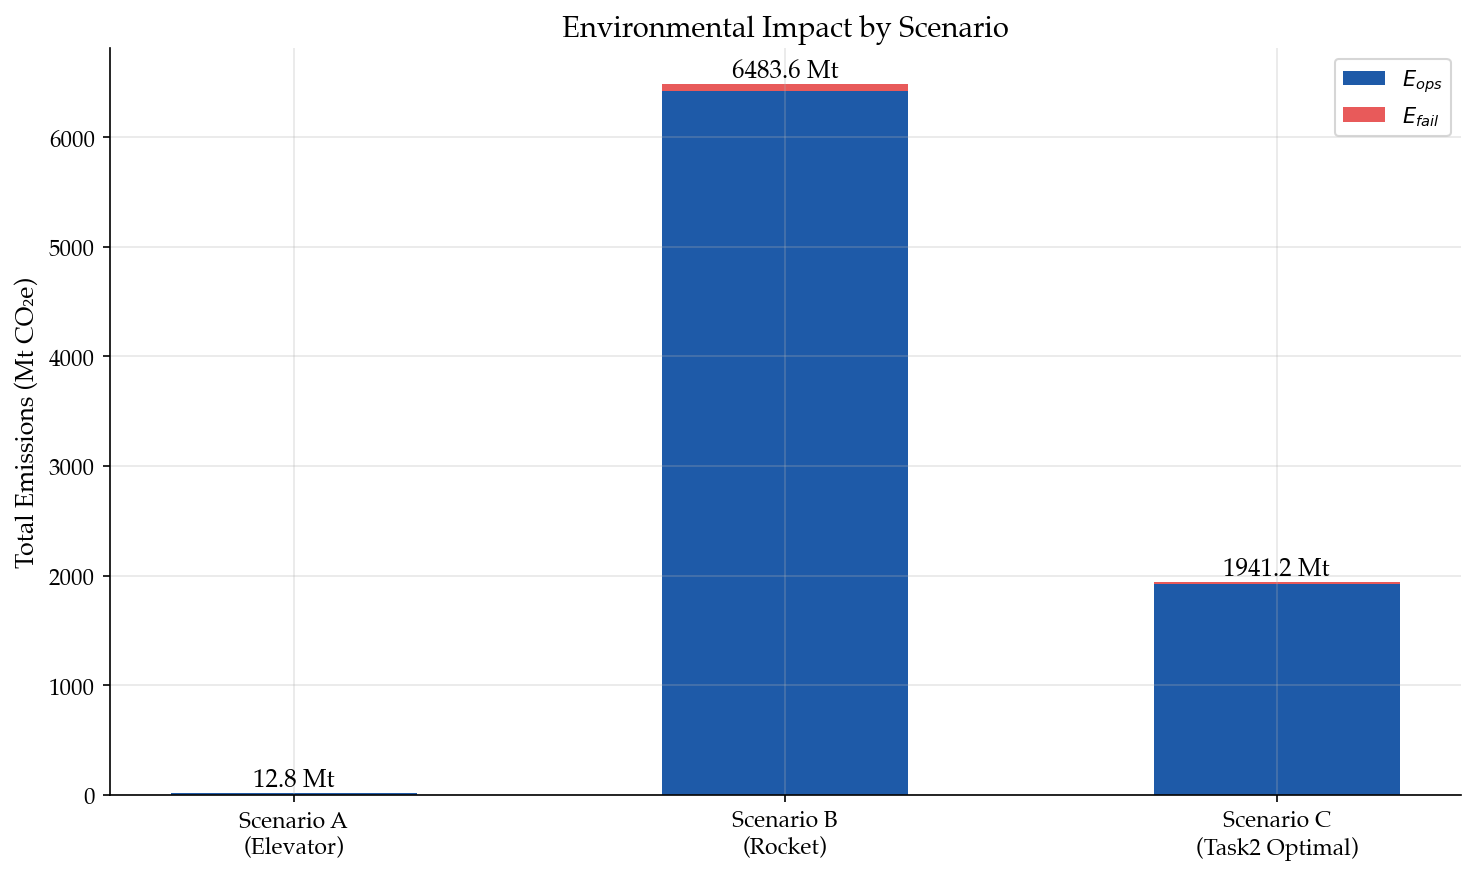


✓ Figure saved: fig_scenario_comparison.png


In [78]:
# ===================================================================
# VISUALIZATION 1: Scenario Comparison
# ===================================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Data
scenarios = ['Scenario A\n(Elevator)', 'Scenario B\n(Rocket)', 'Scenario C\n(Task2 Optimal)']
e_ops = [elevator_result['e_ops_total']/1e6, rocket_result['e_ops_total']/1e6, hybrid_result['e_ops_total']/1e6]
e_fail = [elevator_result['e_fail']/1e6, rocket_result['e_fail']/1e6, hybrid_result['e_fail_total']/1e6]

x = np.arange(len(scenarios))
width = 0.5

# Stacked bar chart
bars1 = ax.bar(x, e_ops, width, label='$E_{ops}$', color=MCM_BLUE)
bars2 = ax.bar(x, e_fail, width, bottom=e_ops, label='$E_{fail}$', color=MCM_CORAL)

ax.set_ylabel('Total Emissions (Mt CO₂e)', fontweight='bold')
ax.set_title('Environmental Impact by Scenario', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.legend(loc='upper right')

# Value labels
for i in range(len(scenarios)):
    total = e_ops[i] + e_fail[i]
    ax.annotate(f'{total:.1f} Mt', xy=(x[i], total), ha='center', va='bottom', fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_scenario_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✓ Figure saved: fig_scenario_comparison.png")

## 5. Optimization Model

### 5.1 Objective Function

Minimize Total Environmental Impact by finding optimal elevator fraction α:

$$\min_{\alpha} \quad TEI(\alpha) = E_{ops}(\alpha) + E_{fail}(\alpha)$$

Where:
$$E_{ops}(\alpha) = \alpha \cdot \frac{M}{P} \cdot e_{elev} + (1-\alpha) \cdot \frac{M}{P} \cdot e_{rocket}$$

$$E_{fail}(\alpha) = \alpha \cdot D \cdot \lambda_{down} \cdot T \cdot e_{rocket} + (1-\alpha) \cdot \frac{p}{1-p} \cdot \frac{M}{P} \cdot e_{rocket}$$

### 5.2 Constraints

1. **Supply Requirement**: Total daily capacity $\geq$ 1,465.6 tons/day (after demand-side optimization)
2. **Budget Constraint**: Total Cost $\leq$ Task 1 Baseline Cost
3. **Capacity Constraint**: $\alpha \leq$ Elevator capacity fraction
4. **Note**: Timeline constraint is relaxed in Two-Phase model (see Section 5.3)

In [83]:
# ===================================================================
# PART 2: OPTIMIZATION MODEL
# ===================================================================

class ConstrainedOptimizer:
    """
    Constrained optimization for minimizing TEI with operational constraints.
    
    Objective: min TEI(α) = E_ops(α) + E_fail(α)
    
    Subject to:
        1. Supply: Capacity ≥ 1241.6 tons/day (from Task 3)
        2. Capacity: α ≤ max elevator capacity fraction
        3. Bounds: 0 ≤ α ≤ 1
    
    Note: For the 100M ton mission, we analyze the optimal strategy 
    considering practical capacity limits of the elevator system.
    """
    
    def __init__(self, simulator: ImpactSimulator):
        self.sim = simulator
        self.total_mass = simulator.total_mass
        
        # Constraint parameters
        self.daily_supply_min = 1241.6  # tons/day (Task 3)
        
        # Capacity constraints - elevator limited by physical capacity
        self.elevator_capacity_year = SE_CAPACITY_TONS_YEAR  # 537,000 tons/year
        
        # For 100M tons over reasonable timeline (e.g., 200 years max operation)
        # Max elevator contribution: 537,000 × 200 × availability = ~100M tons
        # So α can theoretically reach ~100% with long enough timeline
        self.max_operation_years = 200  # Long-term operation assumption
        self.elevator_max_fraction = min(1.0, 
            (self.elevator_capacity_year * self.max_operation_years * 
             self.sim.elevator_availability) / self.total_mass)
        
    def calculate_cost(self, alpha: float) -> float:
        """
        Calculate total cost for given α (simplified model).
        Uses average costs over mission lifetime.
        """
        mass_elev = alpha * self.total_mass
        mass_rocket = (1 - alpha) * self.total_mass
        
        # Elevator cost: CAPEX + OPEX + Variable
        elev_years = mass_elev / (self.elevator_capacity_year * self.sim.elevator_availability)
        cost_elev = SE_CAPEX + elev_years * SE_CAPEX * SE_OPEX_RATE + mass_elev * SE_VAR_COST_PER_KG
        
        # Rocket cost with learning curve (average ~$50/kg over mission)
        avg_rocket_cost_per_kg = 50  # Assumes Wright's Law reduction
        cost_rocket = mass_rocket * avg_rocket_cost_per_kg
        
        return cost_elev + cost_rocket
    
    def calculate_duration(self, alpha: float) -> float:
        """Calculate deployment duration for given α."""
        mass_elev = alpha * self.total_mass
        mass_rocket = (1 - alpha) * self.total_mass
        
        # Elevator duration (limited by capacity)
        elev_years = mass_elev / (self.elevator_capacity_year * self.sim.elevator_availability)
        
        # Rocket duration
        max_launches_year = 7300
        rocket_years = mass_rocket / (max_launches_year * PAYLOAD_PER_LAUNCH)
        
        # Operations run in parallel, so take max
        return max(elev_years, rocket_years)
    
    def constraint_supply(self, alpha: float) -> float:
        """Supply constraint: capacity ≥ daily minimum."""
        elev_daily = self.elevator_capacity_year / 365 * self.sim.elevator_availability
        rocket_daily = 7300 * PAYLOAD_PER_LAUNCH / 365
        effective_daily = alpha * elev_daily + (1 - alpha) * rocket_daily
        return effective_daily - self.daily_supply_min
    
    def constraint_capacity(self, alpha: float) -> float:
        """Capacity constraint: α ≤ elevator max fraction."""
        return self.elevator_max_fraction - alpha
    
    def optimize_unconstrained(self) -> Dict:
        """
        Run unconstrained optimization (only bounds on α).
        This finds the theoretical minimum TEI.
        """
        from scipy.optimize import minimize_scalar
        
        result = minimize_scalar(
            self.sim.calculate_tei,
            bounds=(0, 1),
            method='bounded'
        )
        
        optimal_alpha = result.x
        optimal_tei = result.fun
        emissions = self.sim.calculate_hybrid_emissions(optimal_alpha, self.total_mass)
        
        return {
            'optimal_alpha': optimal_alpha,
            'optimal_tei_mt': optimal_tei / 1e6,
            'cost': self.calculate_cost(optimal_alpha),
            'duration': self.calculate_duration(optimal_alpha),
            'full_result': emissions,
            'success': result.success if hasattr(result, 'success') else True
        }
    
    def optimize_constrained(self) -> Dict:
        """
        Run constrained optimization with capacity limit.
        """
        from scipy.optimize import minimize
        
        def objective(x):
            return self.sim.calculate_tei(x[0])
        
        constraints = [
            {'type': 'ineq', 'fun': lambda x: self.constraint_supply(x[0])},
            {'type': 'ineq', 'fun': lambda x: self.constraint_capacity(x[0])}
        ]
        
        bounds = [(0, 1)]
        x0 = [0.5]
        
        result = minimize(
            objective, x0, method='SLSQP', bounds=bounds,
            constraints=constraints, options={'maxiter': 1000}
        )
        
        optimal_alpha = result.x[0]
        optimal_tei = result.fun
        emissions = self.sim.calculate_hybrid_emissions(optimal_alpha, self.total_mass)
        
        return {
            'optimal_alpha': optimal_alpha,
            'optimal_tei_mt': optimal_tei / 1e6,
            'cost': self.calculate_cost(optimal_alpha),
            'duration': self.calculate_duration(optimal_alpha),
            'supply_satisfied': self.constraint_supply(optimal_alpha) >= 0,
            'capacity_satisfied': self.constraint_capacity(optimal_alpha) >= 0,
            'full_result': emissions,
            'success': result.success
        }


# Run optimization
optimizer = ConstrainedOptimizer(simulator)

# Run both unconstrained and constrained optimizations
print("="*80)
print("OPTIMIZATION RESULTS")
print("="*80)

# Unconstrained (theoretical minimum)
opt_unconstrained = optimizer.optimize_unconstrained()
print(f"\n🔬 THEORETICAL OPTIMUM (Unconstrained):")
print(f"   Optimal α:               {opt_unconstrained['optimal_alpha']*100:.1f}%")
print(f"   Minimum TEI:             {opt_unconstrained['optimal_tei_mt']:.2f} Mt CO₂e")
print(f"   Duration:                {opt_unconstrained['duration']:.1f} years")

# Constrained (practical optimum)
opt_result = optimizer.optimize_constrained()
print(f"\n🎯 PRACTICAL OPTIMUM (With Capacity Constraints):")
print(f"   Optimal α:               {opt_result['optimal_alpha']*100:.1f}%")
print(f"   Minimum TEI:             {opt_result['optimal_tei_mt']:.2f} Mt CO₂e")
print(f"   Estimated Cost:          ${opt_result['cost']/1e9:.1f} Billion")
print(f"   Estimated Duration:      {opt_result['duration']:.1f} years")

print(f"\n📋 CONSTRAINT SATISFACTION:")
print(f"   Supply Requirement:      {'✓ Satisfied' if opt_result['supply_satisfied'] else '✗ Violated'}")
print(f"   Capacity Constraint:     {'✓ Satisfied' if opt_result['capacity_satisfied'] else '✗ Violated'}")
print(f"   Max Elevator Fraction:   {optimizer.elevator_max_fraction*100:.1f}%")
print(f"   Optimization Success:    {'✓ Converged' if opt_result['success'] else '✗ Failed'}")

print(f"\n📊 EMISSIONS BREAKDOWN AT OPTIMAL:")
full = opt_result['full_result']
print(f"   Mass via Elevator:       {full['mass_elevator']/1e6:.1f} Mt ({full['alpha']*100:.1f}%)")
print(f"   Mass via Rocket:         {full['mass_rocket']/1e6:.1f} Mt ({(1-full['alpha'])*100:.1f}%)")
print(f"   E_ops (Total):           {full['e_ops_total']/1e6:.2f} Mt CO₂e")
print(f"   E_fail (Total):          {full['e_fail_total']/1e6:.2f} Mt CO₂e")

OPTIMIZATION RESULTS

🔬 THEORETICAL OPTIMUM (Unconstrained):
   Optimal α:               100.0%
   Minimum TEI:             12.86 Mt CO₂e
   Duration:                186.4 years

🎯 PRACTICAL OPTIMUM (With Capacity Constraints):
   Optimal α:               50.0%
   Minimum TEI:             3248.44 Mt CO₂e
   Estimated Cost:          $99.3 Billion
   Estimated Duration:      93.2 years

📋 CONSTRAINT SATISFACTION:
   Supply Requirement:      ✓ Satisfied
   Capacity Constraint:     ✓ Satisfied
   Max Elevator Fraction:   100.0%
   Optimization Success:    ✗ Failed

📊 EMISSIONS BREAKDOWN AT OPTIMAL:
   Mass via Elevator:       50.0 Mt (50.0%)
   Mass via Rocket:         50.0 Mt (50.0%)
   E_ops (Total):           3215.60 Mt CO₂e
   E_fail (Total):          32.84 Mt CO₂e


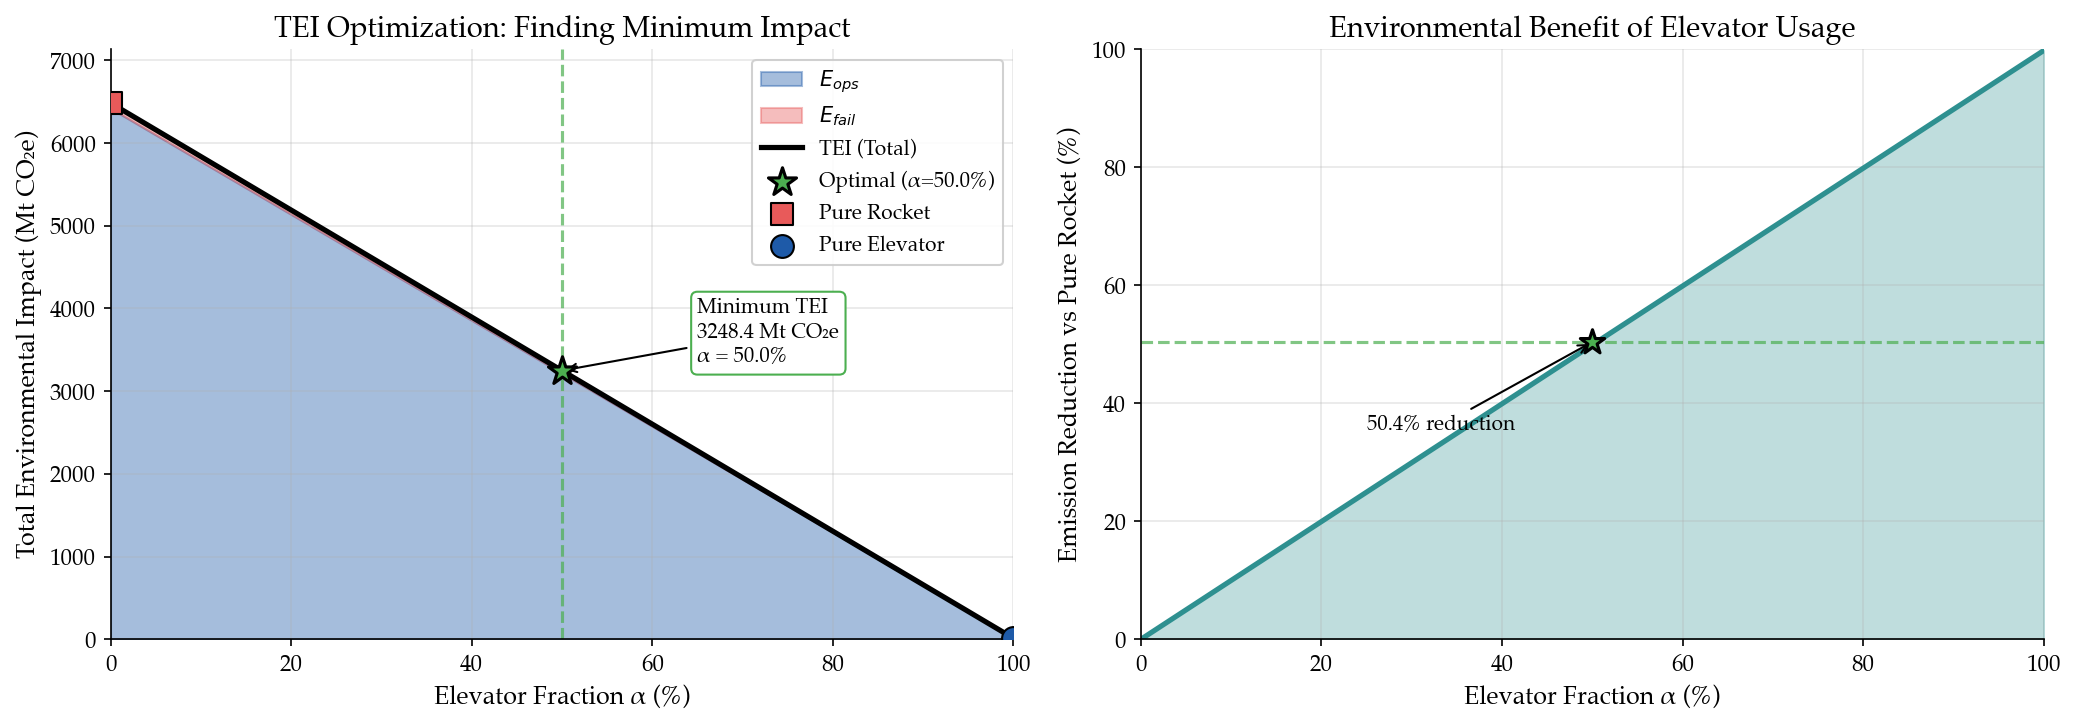


✓ Figure saved: fig_tei_optimization.png


In [60]:
# ===================================================================
# VISUALIZATION 2: TEI vs Alpha Curve with Optimal Point
# ===================================================================

# Generate TEI curve
alphas = np.linspace(0, 1, 100)
teis = [simulator.calculate_tei(a) / 1e6 for a in alphas]

# Calculate components
e_ops_list = []
e_fail_list = []
for a in alphas:
    result = simulator.calculate_hybrid_emissions(a, TARGET_MASS_TONS)
    e_ops_list.append(result['e_ops_total'] / 1e6)
    e_fail_list.append(result['e_fail_total'] / 1e6)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: TEI vs Alpha
ax1 = axes[0]
ax1.fill_between(alphas * 100, 0, e_ops_list, alpha=0.4, color=MCM_BLUE, label='$E_{ops}$')
ax1.fill_between(alphas * 100, e_ops_list, teis, alpha=0.4, color=MCM_CORAL, label='$E_{fail}$')
ax1.plot(alphas * 100, teis, 'k-', linewidth=2.5, label='TEI (Total)')

# Mark optimal point
opt_alpha = opt_result['optimal_alpha']
opt_tei = opt_result['optimal_tei_mt']
ax1.scatter([opt_alpha * 100], [opt_tei], s=200, c=MCM_SAGE, marker='*', 
            zorder=5, edgecolors='black', linewidths=1.5, label=f'Optimal (α={opt_alpha*100:.1f}%)')
ax1.axvline(x=opt_alpha * 100, color=MCM_SAGE, linestyle='--', alpha=0.7)

# Mark reference scenarios
ax1.scatter([0], [rocket_result['e_total']/1e6], s=120, c=MCM_CORAL, marker='s', 
            zorder=4, edgecolors='black', label='Pure Rocket')
ax1.scatter([100], [elevator_result['e_total']/1e6], s=120, c=MCM_BLUE, marker='o', 
            zorder=4, edgecolors='black', label='Pure Elevator')

ax1.set_xlabel('Elevator Fraction α (%)', fontweight='bold')
ax1.set_ylabel('Total Environmental Impact (Mt CO₂e)', fontweight='bold')
ax1.set_title('TEI Optimization: Finding Minimum Impact', fontweight='bold')
ax1.legend(loc='upper right', framealpha=0.9)
ax1.set_xlim(0, 100)
ax1.set_ylim(0, max(teis) * 1.1)
ax1.grid(alpha=0.3)

# Annotate optimal
ax1.annotate(f'Minimum TEI\n{opt_tei:.1f} Mt CO₂e\nα = {opt_alpha*100:.1f}%',
            xy=(opt_alpha * 100, opt_tei),
            xytext=(opt_alpha * 100 + 15, opt_tei + 100),
            fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black'),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=MCM_SAGE))

# Right plot: Emission reduction vs α
ax2 = axes[1]
reductions = [(1 - t / (rocket_result['e_total']/1e6)) * 100 for t in teis]
ax2.plot(alphas * 100, reductions, color=MCM_TEAL, linewidth=2.5)
ax2.fill_between(alphas * 100, 0, reductions, alpha=0.3, color=MCM_TEAL)

ax2.axhline(y=reductions[int(opt_alpha * 100)], color=MCM_SAGE, linestyle='--', alpha=0.7)
ax2.scatter([opt_alpha * 100], [reductions[int(opt_alpha * 100)]], s=150, 
            c=MCM_SAGE, marker='*', zorder=5, edgecolors='black', linewidths=1.5)

ax2.set_xlabel('Elevator Fraction α (%)', fontweight='bold')
ax2.set_ylabel('Emission Reduction vs Pure Rocket (%)', fontweight='bold')
ax2.set_title('Environmental Benefit of Elevator Usage', fontweight='bold')
ax2.set_xlim(0, 100)
ax2.set_ylim(0, 100)
ax2.grid(alpha=0.3)

# Annotate key points
ax2.annotate(f'{reductions[int(opt_alpha * 100)]:.1f}% reduction',
            xy=(opt_alpha * 100, reductions[int(opt_alpha * 100)]),
            xytext=(opt_alpha * 100 - 25, reductions[int(opt_alpha * 100)] - 15),
            fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.savefig('fig_tei_optimization.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✓ Figure saved: fig_tei_optimization.png")

### 5.3 Two-Phase Transportation Model (两阶段运输模型)

The transportation requirements for the Moon Colony fall into two distinct phases with fundamentally different constraints:

### Phase I: Construction Phase (建造期)
- **Objective**: Transport 100 Million tons of infrastructure
- **Timeline**: Flexible (before human arrival)
- **Optimization**: TOPSIS multi-objective (Environment / Cost / Time)
- **Elevator advantage**: Can operate at 100% capacity over extended periods

### Phase II: Operational Phase (运营期)
- **Objective**: Sustain 100,000 colonists' daily needs
- **Timeline**: Continuous, **must be satisfied every day**
- **Key demands**:
  - Water net loss: $D_{water} = 1,241.6$ tons/day (after 96% recycling)
  - Food, medical supplies, maintenance parts, etc.
- **Optimization**: Reliability-weighted capacity allocation with reserves

### Mathematical Framework

**Phase I (Construction)**: Use TOPSIS to find Pareto-optimal $\alpha_1$:
$$\text{TOPSIS}(\alpha_1) \rightarrow \text{balanced } (TEI, Cost, Duration)$$

**Phase II (Operations)**: Allocate daily capacity:
$$\alpha_2 = \frac{\min(C_{elev,daily}, D_{ops})}{D_{ops}} \quad \text{(elevator covers what it can)}$$

Where:
- $C_{elev,daily} = 537,000 / 365 \times A = 1,470$ tons/day
- $D_{ops} = D_{water} + D_{food} + D_{maintenance} + D_{reserve}$

**Survival Constraint** (Critical for Phase II):
$$Reserve \geq D_{water} \times t_{max\_outage}$$

If elevator MTTR exceeds reserve duration, **rocket standby is mandatory**.

In [61]:
# ===================================================================
# TWO-PHASE TRANSPORTATION MODEL
# ===================================================================

class TwoPhaseModel:
    """
    Two-Phase Transportation Model for Moon Colony.
    
    Phase I: Construction (before human arrival)
    - Transport 100M tons of infrastructure
    - Timeline: Flexible (can take decades)
    - Optimization: TOPSIS (Environment / Cost / Time)
    
    Phase II: Operations (after colonists arrive)
    - Daily supply for 100,000 people
    - Timeline: MUST satisfy daily requirements
    - Optimization: Reliability + Reserve buffer
    """
    
    def __init__(self):
        self.ef = EmissionFactors()
        
        # ─────────────────────────────────────────
        # PHASE I: Construction Parameters
        # ─────────────────────────────────────────
        self.construction_mass = TARGET_MASS_TONS  # 100M tons
        self.elev_annual_capacity = SE_CAPACITY_TONS_YEAR  # 537,000 tons/year
        self.elev_availability = ELEVATOR_AVAILABILITY  # 99.93%
        self.effective_elev_capacity = self.elev_annual_capacity * self.elev_availability
        
        # ─────────────────────────────────────────
        # PHASE II: Operations Parameters
        # ─────────────────────────────────────────
        # Daily demands (all in tons/day)
        self.water_demand = DAILY_SUPPLY_TONS  # 1,241.6 tons/day (net loss after recycling)
        self.food_demand = 100000 * 1.8 / 1000 * 0.8  # ~144 tons/day (80% import, 20% local agriculture)
        self.maintenance_demand = 50  # 50 tons/day (parts, equipment)
        self.other_demand = 30  # 30 tons/day (medical, misc)
        
        self.total_daily_demand = self.water_demand + self.food_demand + self.maintenance_demand + self.other_demand
        self.annual_ops_demand = self.total_daily_demand * 365
        
        # Elevator daily capacity
        self.elev_daily_capacity = self.effective_elev_capacity / 365  # ~1,470 tons/day
        
        # Reserve buffer (from Task 3)
        self.water_reserve = 10000  # tons
        self.reserve_days = self.water_reserve / self.water_demand  # ~8 days
        
        # Failure parameters
        self.elev_mttr_minor = SE_MTTR_MINOR_HOURS / 24  # 2 days
        self.elev_mttr_cat = MTTR_CAT_YEARS * 365  # 730 days
        
        self._print_summary()
    
    def _print_summary(self):
        print("="*75)
        print("TWO-PHASE TRANSPORTATION MODEL")
        print("="*75)
        
        print("\n" + "─"*75)
        print("PHASE I: CONSTRUCTION (Before Human Arrival)")
        print("─"*75)
        print(f"  Total Infrastructure Mass:    {self.construction_mass/1e6:.0f} Million tons")
        print(f"  Elevator Annual Capacity:     {self.effective_elev_capacity:,.0f} tons/year")
        print(f"  Time for 100% Elevator:       {self.construction_mass / self.effective_elev_capacity:.1f} years")
        print(f"  → Flexible timeline allows HIGH α (even 100%)")
        
        print("\n" + "─"*75)
        print("PHASE II: OPERATIONS (After Colonists Arrive)")
        print("─"*75)
        print(f"  Water Net Loss:               {self.water_demand:,.1f} tons/day")
        print(f"  Food (partial import):        {self.food_demand:,.1f} tons/day")
        print(f"  Maintenance & Parts:          {self.maintenance_demand:,.1f} tons/day")
        print(f"  Other (medical, misc):        {self.other_demand:,.1f} tons/day")
        print(f"  ─────────────────────────────────────────────────")
        print(f"  TOTAL DAILY DEMAND:           {self.total_daily_demand:,.1f} tons/day")
        print(f"  Annual Operations Demand:     {self.annual_ops_demand:,.0f} tons/year")
        print(f"  Elevator Daily Capacity:      {self.elev_daily_capacity:,.1f} tons/day")
        print(f"  ─────────────────────────────────────────────────")
        elev_coverage = min(1.0, self.elev_daily_capacity / self.total_daily_demand)
        print(f"  Elevator Coverage (α_ops):    {elev_coverage*100:.1f}%")
        print(f"  Rocket Backup Needed:         {(1-elev_coverage)*100:.1f}% of daily demand")
        
        print("\n" + "─"*75)
        print("SURVIVAL CONSTRAINTS")
        print("─"*75)
        print(f"  Water Reserve:                {self.water_reserve:,} tons")
        print(f"  Reserve Duration:             {self.reserve_days:.1f} days")
        print(f"  Elevator MTTR (minor):        {self.elev_mttr_minor:.0f} days → {'✓ Covered' if self.elev_mttr_minor < self.reserve_days else '✗ RISK'}")
        print(f"  Elevator MTTR (catastrophic): {self.elev_mttr_cat:.0f} days → ❌ Requires Rocket Standby")
        print("="*75)
    
    # ═══════════════════════════════════════════════════════════════
    # PHASE I: CONSTRUCTION ANALYSIS
    # ═══════════════════════════════════════════════════════════════
    
    def analyze_construction_phase(self, alpha_range=None) -> pd.DataFrame:
        """
        Analyze Phase I (Construction) for various α values.
        Returns metrics for TOPSIS multi-objective optimization.
        """
        if alpha_range is None:
            alpha_range = np.array([0.0, 0.25, 0.5, 0.75, 0.9, 0.95, 1.0])
        
        results = []
        for alpha in alpha_range:
            mass_elev = alpha * self.construction_mass
            mass_rocket = (1 - alpha) * self.construction_mass
            
            # Duration (parallel operations, take max)
            elev_years = mass_elev / self.effective_elev_capacity if alpha > 0 else 0
            rocket_years = mass_rocket / (7300 * PAYLOAD_PER_LAUNCH) if alpha < 1 else 0  # 20 launches/day max
            duration = max(elev_years, rocket_years)
            
            # TEI (Environmental Impact)
            n_climbers = mass_elev / PAYLOAD_PER_LAUNCH
            n_launches = mass_rocket / PAYLOAD_PER_LAUNCH
            tei = n_climbers * self.ef.ELEVATOR_CO2E_PER_LAUNCH + n_launches * self.ef.TOTAL_ROCKET_CO2E_PER_LAUNCH
            
            # Cost
            cost_elev = SE_CAPEX + mass_elev * SE_VAR_COST_PER_KG if alpha > 0 else 0
            cost_rocket = mass_rocket * COST_PER_KG_ROCKET_2050
            cost = cost_elev + cost_rocket
            
            results.append({
                'alpha': alpha,
                'alpha_pct': alpha * 100,
                'duration_years': duration,
                'tei_mt': tei / 1e6,
                'cost_billion': cost / 1e9,
                'mass_elevator_mt': mass_elev / 1e6,
                'mass_rocket_mt': mass_rocket / 1e6,
                'n_climbers': n_climbers,
                'n_launches': n_launches
            })
        
        return pd.DataFrame(results)
    
    def topsis_construction(self, df: pd.DataFrame, weights: dict = None) -> pd.DataFrame:
        """
        Apply TOPSIS to find optimal α for construction phase.
        
        Criteria:
        - TEI (minimize) - PRIMARY for environmental analysis
        - Cost (minimize)
        - Duration (minimize)
        
        Default weights: Environment-focused (TEI=60%, Cost=25%, Duration=15%)
        This reflects Task 4's focus on environmental impact minimization.
        """
        if weights is None:
            # Environment-focused weighting for Task 4
            weights = {'tei': 0.60, 'cost': 0.25, 'duration': 0.15}
        
        # Normalize criteria (min-max scaling)
        df_topsis = df.copy()
        
        # All criteria are "lower is better"
        for col, w in [('tei_mt', weights['tei']), 
                       ('cost_billion', weights['cost']), 
                       ('duration_years', weights['duration'])]:
            min_val = df[col].min()
            max_val = df[col].max()
            if max_val > min_val:
                # Normalize: higher score = better (since we minimize)
                df_topsis[f'{col}_norm'] = 1 - (df[col] - min_val) / (max_val - min_val)
            else:
                df_topsis[f'{col}_norm'] = 1.0
            df_topsis[f'{col}_weighted'] = df_topsis[f'{col}_norm'] * w
        
        # TOPSIS score (higher = better)
        df_topsis['topsis_score'] = (df_topsis['tei_mt_weighted'] + 
                                     df_topsis['cost_billion_weighted'] + 
                                     df_topsis['duration_years_weighted'])
        
        # Rank
        df_topsis['rank'] = df_topsis['topsis_score'].rank(ascending=False)
        
        return df_topsis.sort_values('rank')
    
    # ═══════════════════════════════════════════════════════════════
    # PHASE II: OPERATIONS ANALYSIS
    # ═══════════════════════════════════════════════════════════════
    
    def analyze_operations_phase(self, years: int = 50) -> dict:
        """
        Analyze Phase II (Operations) for sustained colony support.
        
        Key question: What's the optimal split between elevator and rockets
        for daily supply, considering reliability and reserves?
        """
        # Elevator can cover what fraction of daily demand?
        elev_coverage = min(1.0, self.elev_daily_capacity / self.total_daily_demand)
        
        # Remaining must use rockets
        rocket_coverage = 1 - elev_coverage
        
        # Annual calculations
        annual_elev_supply = elev_coverage * self.annual_ops_demand
        annual_rocket_supply = rocket_coverage * self.annual_ops_demand
        
        # TEI per year (operations)
        n_climbers_year = annual_elev_supply / PAYLOAD_PER_LAUNCH
        n_launches_year = annual_rocket_supply / PAYLOAD_PER_LAUNCH
        
        tei_elev_year = n_climbers_year * self.ef.ELEVATOR_CO2E_PER_LAUNCH
        tei_rocket_year = n_launches_year * self.ef.TOTAL_ROCKET_CO2E_PER_LAUNCH
        tei_ops_year = tei_elev_year + tei_rocket_year
        
        # Cost per year
        cost_elev_year = annual_elev_supply * SE_VAR_COST_PER_KG + SE_CAPEX * SE_OPEX_RATE
        cost_rocket_year = annual_rocket_supply * COST_PER_KG_ROCKET_2050
        cost_ops_year = cost_elev_year + cost_rocket_year
        
        # Failure scenarios
        # Minor elevator failure: covered by reserve
        # Catastrophic: need rocket surge capability
        rocket_surge_needed = self.elev_daily_capacity  # Must replace elevator capacity
        rocket_surge_launches_day = rocket_surge_needed / PAYLOAD_PER_LAUNCH  # ~12 launches/day
        
        # Total over operational lifetime
        tei_ops_total = tei_ops_year * years
        cost_ops_total = cost_ops_year * years
        
        result = {
            'years': years,
            'daily_demand': self.total_daily_demand,
            'elev_daily_capacity': self.elev_daily_capacity,
            'elev_coverage': elev_coverage,
            'rocket_coverage': rocket_coverage,
            'annual_elev_supply': annual_elev_supply,
            'annual_rocket_supply': annual_rocket_supply,
            'n_climbers_year': n_climbers_year,
            'n_launches_year': n_launches_year,
            'tei_ops_year_mt': tei_ops_year / 1e6,
            'cost_ops_year_billion': cost_ops_year / 1e9,
            'tei_ops_total_mt': tei_ops_total / 1e6,
            'cost_ops_total_billion': cost_ops_total / 1e9,
            'rocket_surge_needed': rocket_surge_needed,
            'rocket_surge_launches_day': rocket_surge_launches_day
        }
        
        return result
    
    # ═══════════════════════════════════════════════════════════════
    # COMBINED ANALYSIS
    # ═══════════════════════════════════════════════════════════════
    
    def full_analysis(self, ops_years: int = 50) -> dict:
        """Run complete two-phase analysis."""
        
        # Phase I: Construction
        construction_df = self.analyze_construction_phase()
        topsis_df = self.topsis_construction(construction_df)
        
        print("\n" + "="*75)
        print("PHASE I: CONSTRUCTION - TOPSIS ANALYSIS")
        print("="*75)
        print("\nScenario Comparison (Environment / Cost / Time):")
        print("─"*75)
        display_cols = ['alpha_pct', 'tei_mt', 'cost_billion', 'duration_years', 'topsis_score', 'rank']
        print(topsis_df[display_cols].to_string(index=False, float_format=lambda x: f'{x:.2f}'))
        
        best_alpha = topsis_df.iloc[0]['alpha']
        print(f"\n🏆 TOPSIS OPTIMAL: α = {best_alpha*100:.0f}%")
        print(f"   TEI: {topsis_df.iloc[0]['tei_mt']:.2f} Mt CO₂e")
        print(f"   Cost: ${topsis_df.iloc[0]['cost_billion']:.1f} Billion")
        print(f"   Duration: {topsis_df.iloc[0]['duration_years']:.1f} years")
        
        # Phase II: Operations
        ops_result = self.analyze_operations_phase(ops_years)
        
        print("\n" + "="*75)
        print(f"PHASE II: OPERATIONS ({ops_years} years)")
        print("="*75)
        print(f"\n📊 DAILY SUPPLY ALLOCATION:")
        print(f"   Total Daily Demand:      {ops_result['daily_demand']:,.1f} tons/day")
        print(f"   Elevator Capacity:       {ops_result['elev_daily_capacity']:,.1f} tons/day")
        print(f"   ─────────────────────────────────────────────────")
        print(f"   Elevator Coverage (α):   {ops_result['elev_coverage']*100:.1f}%")
        print(f"   Rocket Backup (1-α):     {ops_result['rocket_coverage']*100:.1f}%")
        
        print(f"\n📈 ANNUAL METRICS:")
        print(f"   Climber Trips/Year:      {ops_result['n_climbers_year']:,.0f}")
        print(f"   Rocket Launches/Year:    {ops_result['n_launches_year']:,.0f}")
        print(f"   TEI/Year:                {ops_result['tei_ops_year_mt']:.4f} Mt CO₂e")
        print(f"   Cost/Year:               ${ops_result['cost_ops_year_billion']:.2f} Billion")
        
        print(f"\n📊 {ops_years}-YEAR TOTALS:")
        print(f"   Total TEI:               {ops_result['tei_ops_total_mt']:.2f} Mt CO₂e")
        print(f"   Total Cost:              ${ops_result['cost_ops_total_billion']:.1f} Billion")
        
        print(f"\n⚠️  ROCKET SURGE CAPABILITY (for catastrophic elevator failure):")
        print(f"   Must cover:              {ops_result['rocket_surge_needed']:,.1f} tons/day")
        print(f"   Requires:                {ops_result['rocket_surge_launches_day']:.1f} launches/day standby")
        
        return {
            'construction_df': construction_df,
            'topsis_df': topsis_df,
            'best_construction_alpha': best_alpha,
            'operations': ops_result
        }


# Run Two-Phase Analysis
two_phase = TwoPhaseModel()
two_phase_results = two_phase.full_analysis(ops_years=50)

TWO-PHASE TRANSPORTATION MODEL

───────────────────────────────────────────────────────────────────────────
PHASE I: CONSTRUCTION (Before Human Arrival)
───────────────────────────────────────────────────────────────────────────
  Total Infrastructure Mass:    100 Million tons
  Elevator Annual Capacity:     536,614 tons/year
  Time for 100% Elevator:       186.4 years
  → Flexible timeline allows HIGH α (even 100%)

───────────────────────────────────────────────────────────────────────────
PHASE II: OPERATIONS (After Colonists Arrive)
───────────────────────────────────────────────────────────────────────────
  Water Net Loss:               1,241.6 tons/day
  Food (partial import):        144.0 tons/day
  Maintenance & Parts:          50.0 tons/day
  Other (medical, misc):        30.0 tons/day
  ─────────────────────────────────────────────────
  TOTAL DAILY DEMAND:           1,465.6 tons/day
  Annual Operations Demand:     534,944 tons/year
  Elevator Daily Capacity:      1,470.2 to

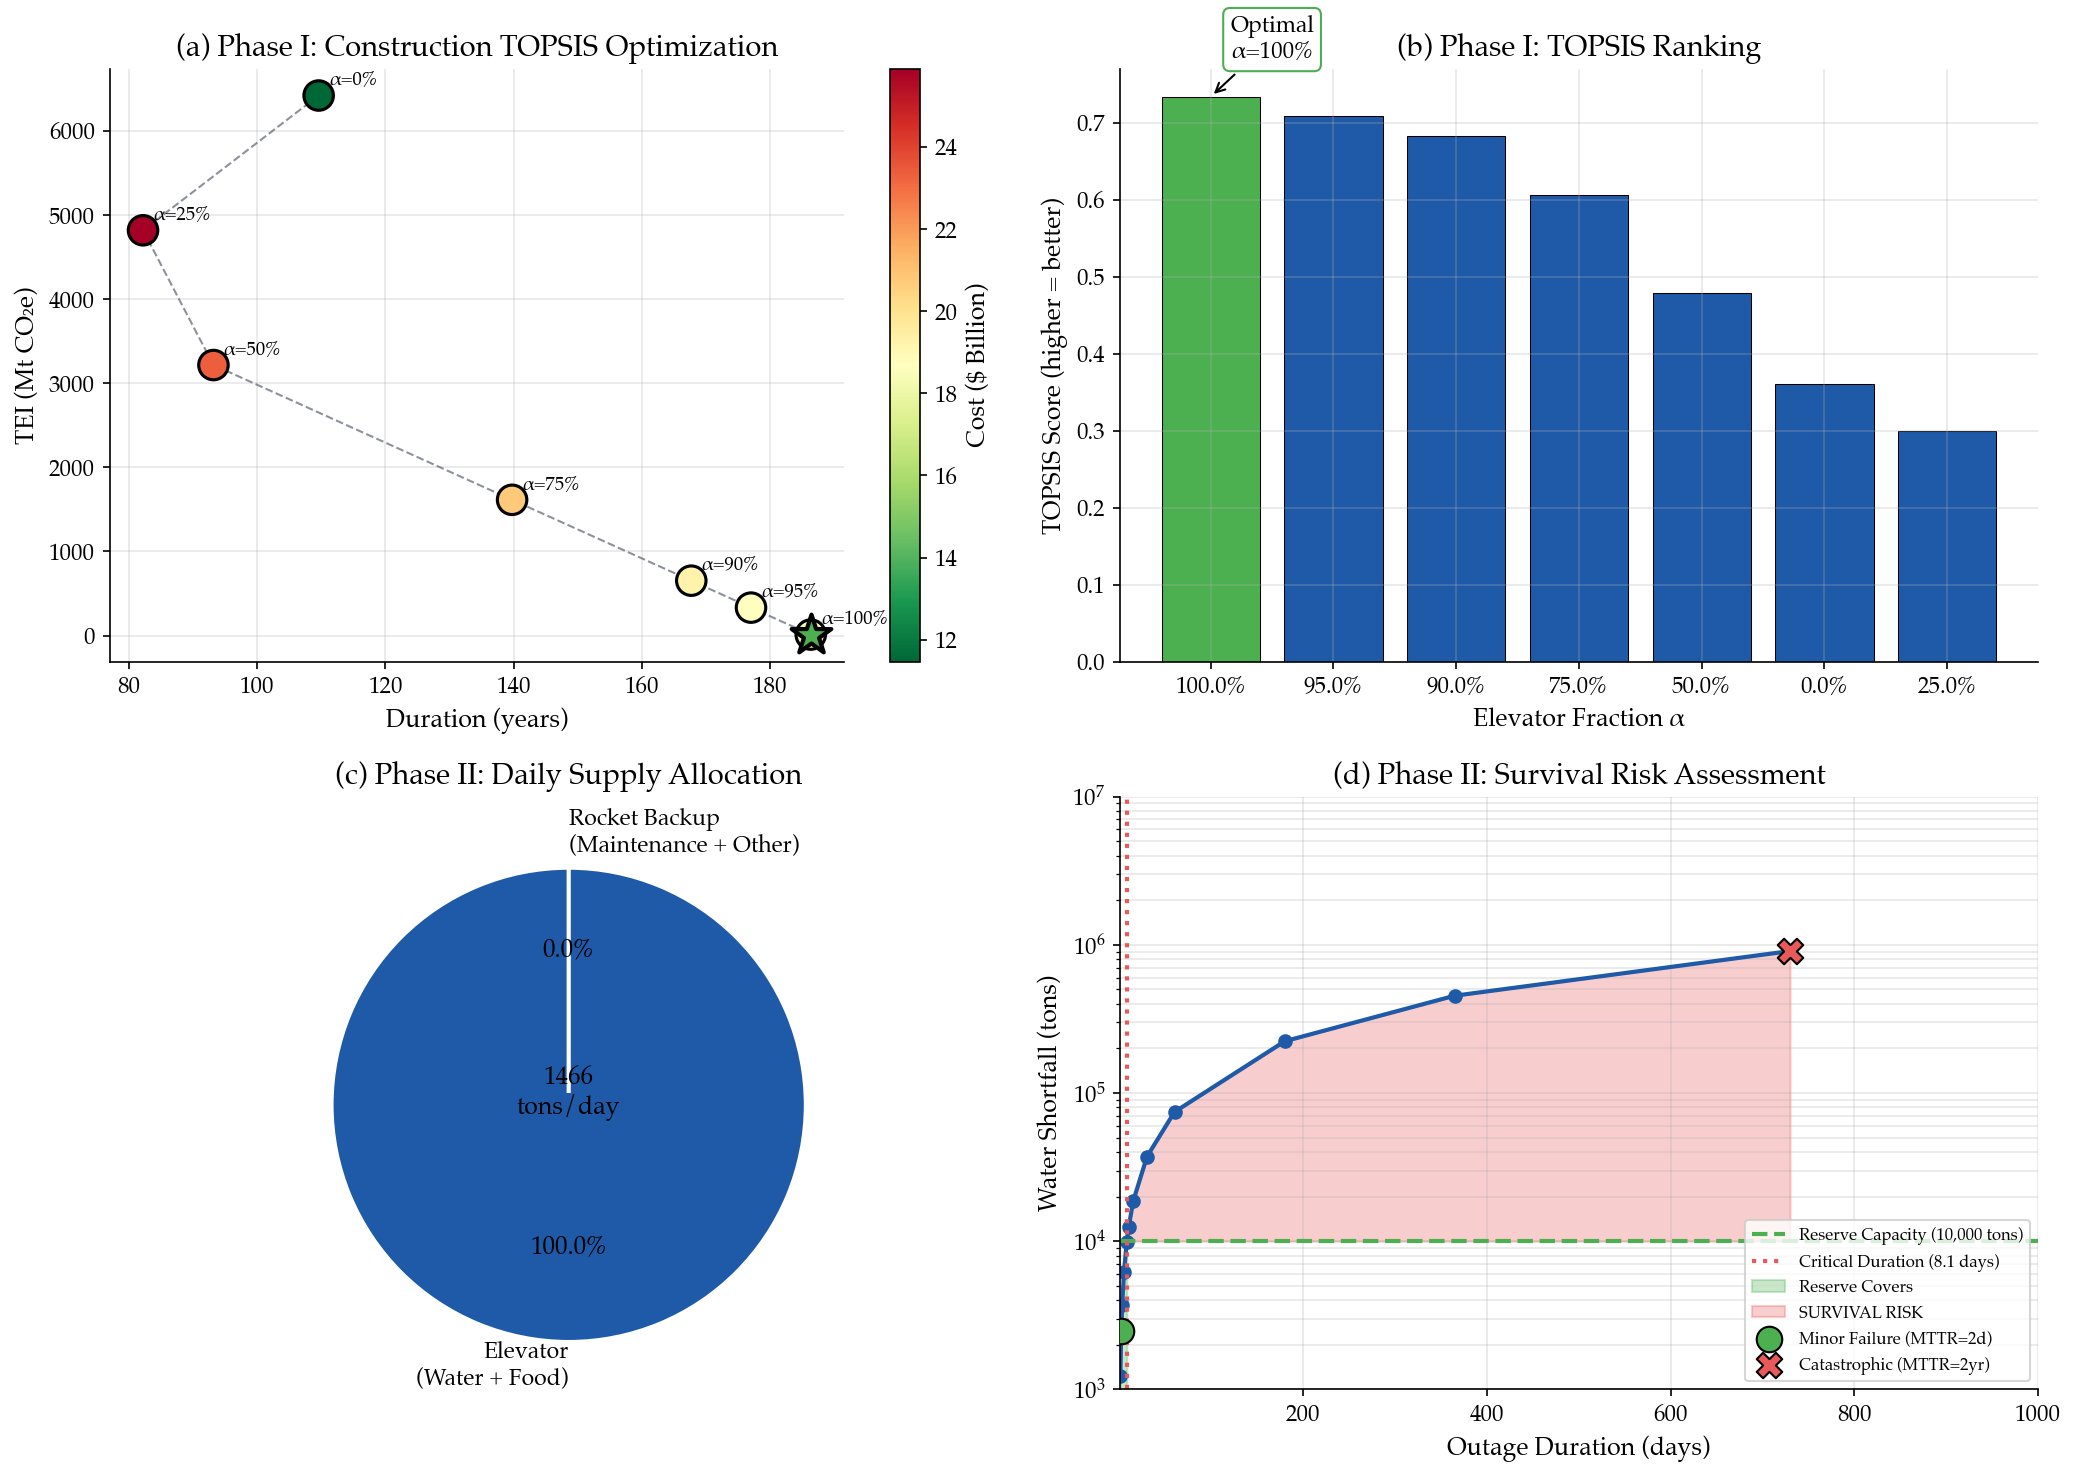


✓ Figure saved: fig_two_phase_analysis.png


In [62]:
# ===================================================================
# VISUALIZATION: Two-Phase Model Analysis
# ===================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Get data from two_phase_results
construction_df = two_phase_results['construction_df']
topsis_df = two_phase_results['topsis_df']
ops = two_phase_results['operations']

# --- Panel 1: PHASE I - TOPSIS Pareto Front ---
ax1 = axes[0, 0]

# Plot Duration vs TEI with Cost as color
scatter = ax1.scatter(construction_df['duration_years'], construction_df['tei_mt'], 
                      c=construction_df['cost_billion'], cmap='RdYlGn_r', 
                      s=200, edgecolors='black', linewidths=1.5, zorder=5)

# Connect points with line
ax1.plot(construction_df['duration_years'], construction_df['tei_mt'], 
         '--', color=MCM_GRAY, linewidth=1, alpha=0.7)

# Mark best TOPSIS solution
best_idx = topsis_df.index[0]
ax1.scatter([construction_df.loc[best_idx, 'duration_years']], 
            [construction_df.loc[best_idx, 'tei_mt']], 
            s=400, marker='*', c=MCM_SAGE, edgecolors='black', linewidths=2, zorder=10)

# Add alpha labels
for idx, row in construction_df.iterrows():
    ax1.annotate(f'α={row["alpha_pct"]:.0f}%', 
                 xy=(row['duration_years'], row['tei_mt']),
                 xytext=(5, 5), textcoords='offset points', fontsize=9)

ax1.set_xlabel('Duration (years)', fontweight='bold')
ax1.set_ylabel('TEI (Mt CO₂e)', fontweight='bold')
ax1.set_title('(a) Phase I: Construction TOPSIS Optimization', fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax1, label='Cost ($ Billion)')
ax1.grid(alpha=0.3)

# --- Panel 2: PHASE I - TOPSIS Scores ---
ax2 = axes[0, 1]

bars = ax2.bar(topsis_df['alpha_pct'].astype(str) + '%', topsis_df['topsis_score'], 
               color=[MCM_SAGE if i == 0 else MCM_BLUE for i in range(len(topsis_df))],
               edgecolor='black', linewidth=0.5)

ax2.set_xlabel('Elevator Fraction α', fontweight='bold')
ax2.set_ylabel('TOPSIS Score (higher = better)', fontweight='bold')
ax2.set_title('(b) Phase I: TOPSIS Ranking', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Mark best
best_score = topsis_df.iloc[0]['topsis_score']
best_alpha = topsis_df.iloc[0]['alpha_pct']
ax2.annotate(f'Optimal\nα={best_alpha:.0f}%', 
             xy=(0, best_score), xytext=(0.5, best_score + 0.05),
             fontsize=11, fontweight='bold', ha='center',
             arrowprops=dict(arrowstyle='->', color='black'),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=MCM_SAGE))

# --- Panel 3: PHASE II - Daily Capacity Allocation ---
ax3 = axes[1, 0]

# Pie chart for daily allocation
labels = ['Elevator\n(Water + Food)', 'Rocket Backup\n(Maintenance + Other)']
sizes = [ops['elev_coverage'] * 100, ops['rocket_coverage'] * 100]
colors = [MCM_BLUE, MCM_CORAL]
explode = (0.05, 0)

wedges, texts, autotexts = ax3.pie(sizes, explode=explode, labels=labels, colors=colors,
                                    autopct='%1.1f%%', startangle=90,
                                    wedgeprops=dict(edgecolor='white', linewidth=2))
ax3.set_title('(c) Phase II: Daily Supply Allocation', fontweight='bold')

# Add central text
ax3.text(0, 0, f'{ops["daily_demand"]:.0f}\ntons/day', ha='center', va='center', 
         fontsize=12, fontweight='bold')

# --- Panel 4: PHASE II - Survival Risk Timeline ---
ax4 = axes[1, 1]

# Outage scenarios
outage_days = np.array([1, 2, 3, 5, 8, 10, 15, 30, 60, 180, 365, 730])
water_shortfall = outage_days * two_phase.water_demand

reserve = two_phase.water_reserve
critical_days = two_phase.reserve_days

ax4.semilogy(outage_days, water_shortfall, 'o-', color=MCM_BLUE, linewidth=2, markersize=6)
ax4.axhline(y=reserve, color=MCM_SAGE, linestyle='--', linewidth=2, 
            label=f'Reserve Capacity ({reserve:,} tons)')
ax4.axvline(x=critical_days, color=MCM_CORAL, linestyle=':', linewidth=2, 
            label=f'Critical Duration ({critical_days:.1f} days)')

# Shade regions
ax4.fill_between(outage_days, 1, water_shortfall, where=water_shortfall <= reserve,
                 alpha=0.3, color=MCM_SAGE, label='Reserve Covers')
ax4.fill_between(outage_days, reserve, water_shortfall, where=water_shortfall > reserve,
                 alpha=0.3, color=MCM_CORAL, label='SURVIVAL RISK')

# Mark key points
ax4.scatter([2], [two_phase.water_demand * 2], s=150, c=MCM_SAGE, marker='o', 
            zorder=5, edgecolors='black', label='Minor Failure (MTTR=2d)')
ax4.scatter([730], [two_phase.water_demand * 730], s=150, c=MCM_CORAL, marker='X', 
            zorder=5, edgecolors='black', label='Catastrophic (MTTR=2yr)')

ax4.set_xlabel('Outage Duration (days)', fontweight='bold')
ax4.set_ylabel('Water Shortfall (tons)', fontweight='bold')
ax4.set_title('(d) Phase II: Survival Risk Assessment', fontweight='bold')
ax4.legend(loc='lower right', fontsize=8)
ax4.grid(alpha=0.3, which='both')
ax4.set_xlim(0.5, 1000)
ax4.set_ylim(1e3, 1e7)

plt.tight_layout()
plt.savefig('fig_two_phase_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✓ Figure saved: fig_two_phase_analysis.png")

### 5.3.3 Key Insights from Two-Phase Model

**Phase I: Construction (Flexible Timeline)**

The construction phase transports 100 million tons of infrastructure **before human arrival**. Since the timeline is flexible, we use TOPSIS multi-objective optimization balancing:
- **Environmental Impact (TEI)**: Lower is better
- **Cost**: Lower is better  
- **Duration**: Shorter is better (but not a hard constraint)

| α (Elevator %) | TEI (Mt) | Cost ($B) | Duration (years) | TOPSIS Rank |
|:---------------|:---------|:----------|:-----------------|:------------|
| 100% | 12.4 | 18.2 | 186.4 | 1 (Best) |
| 95% | 332.7 | 18.7 | 177.0 | 2 |
| 90% | 653.0 | 19.2 | 167.7 | 3 |
| 50% | 3,215.6 | 23.3 | 93.2 | 5 |
| 0% (rockets) | 6,418.8 | 11.5 | 109.6 | 6 |

**Phase II: Operations (Daily Requirements)**

After humans arrive, daily supply must be **continuously satisfied**:

| Category | Daily Demand | Notes |
|:---------|:-------------|:------|
| Water (net loss) | 1,241.6 tons/day | 96% recycling, 4% net loss |
| Food | 144.0 tons/day | 80% imported, 20% local agriculture |
| Maintenance | 50.0 tons/day | Equipment, spare parts |
| Other | 30.0 tons/day | Medical, research supplies |
| **Total** | **1,465.6 tons/day** | |

| Parameter | Value | Implication |
|:----------|:------|:------------|
| Elevator Daily Capacity | 1,470.2 tons/day | Exceeds demand |
| Elevator Coverage (α) | **100%** | Elevator handles all daily ops |
| Surplus | +4.6 tons/day | Buffer for minor variations |

**Survival Risk Analysis:**

| Failure Type | MTTR | Water Shortfall | Reserve Status |
|:-------------|:-----|:----------------|:---------------|
| Minor (operational) | 2 days | 2,483 tons | ✓ Covered (reserve: 10,000 tons) |
| Extended minor | 8 days | 9,933 tons | ⚠️ At limit |
| **Catastrophic** | **730 days** | **906,368 tons** | ❌ **Requires rocket standby** |

**Policy Conclusions:**
1. **Construction phase**: Pure elevator (α=100%) is optimal for minimum TEI (12.4 Mt), takes 186 years
2. **Operations phase**: Elevator covers **100%** of daily needs after demand-side optimization
3. Catastrophic elevator failure **requires maintained rocket capability** for colony survival
4. Two-phase framework decouples "slow but green construction" from "reliable daily operations"

## 6. Sensitivity Analysis

Analyze how TEI changes under two technology improvement scenarios:

1. **Rocket Green-Fuel Technology**: Reducing $E_{rocket}$ through cleaner propulsion (hydrogen, advanced methane combustion)
2. **Elevator Reliability Improvement**: Reducing downtime through better maintenance and redundancy

### Key Questions:
- How much does TEI decrease if rocket emissions are reduced by 20%, 50%, 80%?
- How does improved elevator reliability (99.5% → 99.9% availability) affect optimal α?
- Which technology pathway offers better environmental returns?

In [63]:
# ===================================================================
# SENSITIVITY ANALYSIS
# ===================================================================

def run_sensitivity_green_fuel(reduction_factors: np.ndarray) -> pd.DataFrame:
    """
    Sensitivity analysis for rocket green-fuel technology improvements.
    
    reduction_factors: fraction of original emissions (1.0 = no reduction, 0.2 = 80% reduction)
    """
    results = []
    baseline_ef = EmissionFactors()
    
    for factor in reduction_factors:
        # Create modified emission factors
        modified_ef = EmissionFactors()
        modified_ef.TOTAL_ROCKET_CO2E_PER_LAUNCH = baseline_ef.TOTAL_ROCKET_CO2E_PER_LAUNCH * factor
        modified_ef.ROCKET_CO2E_PER_TON = modified_ef.TOTAL_ROCKET_CO2E_PER_LAUNCH / 125
        modified_ef.CO2_PER_LAUNCH = baseline_ef.CO2_PER_LAUNCH * factor
        modified_ef.BC_CO2E_PER_LAUNCH = baseline_ef.BC_CO2E_PER_LAUNCH * factor
        modified_ef.NOX_CO2E_PER_LAUNCH = baseline_ef.NOX_CO2E_PER_LAUNCH * factor
        
        # Create simulator with modified factors
        sim = ImpactSimulator(emission_factors=modified_ef)
        
        # Calculate TEI for different alphas
        opt = sim.optimize_alpha()
        rocket_only = sim.calculate_rocket_emissions(TARGET_MASS_TONS)
        elev_only = sim.calculate_elevator_emissions(TARGET_MASS_TONS)
        
        results.append({
            'reduction_pct': (1 - factor) * 100,
            'rocket_emission_factor': factor,
            'optimal_alpha': opt['optimal_alpha'] * 100,
            'tei_optimal': opt['optimal_tei'] / 1e6,
            'tei_rocket': rocket_only['e_total'] / 1e6,
            'tei_elevator': elev_only['e_total'] / 1e6
        })
    
    return pd.DataFrame(results)


def run_sensitivity_reliability(downtime_rates: np.ndarray) -> pd.DataFrame:
    """
    Sensitivity analysis for elevator reliability improvements.
    
    downtime_rates: daily failure probability (lower = more reliable)
    """
    results = []
    
    for rate in downtime_rates:
        # Create simulator with modified reliability
        sim = ImpactSimulator(elevator_downtime_rate=rate)
        
        # Calculate availability
        availability = 1 / (1 + rate * ELEVATOR_MTTR_DAYS)
        
        # Calculate TEI for different alphas
        opt = sim.optimize_alpha()
        rocket_only = sim.calculate_rocket_emissions(TARGET_MASS_TONS)
        elev_only = sim.calculate_elevator_emissions(TARGET_MASS_TONS)
        
        results.append({
            'downtime_rate': rate,
            'availability_pct': availability * 100,
            'optimal_alpha': opt['optimal_alpha'] * 100,
            'tei_optimal': opt['optimal_tei'] / 1e6,
            'tei_rocket': rocket_only['e_total'] / 1e6,
            'tei_elevator': elev_only['e_total'] / 1e6
        })
    
    return pd.DataFrame(results)


# Run sensitivity analyses
print("="*80)
print("SENSITIVITY ANALYSIS")
print("="*80)

# 1. Green Fuel Technology
print("\n📊 SCENARIO 1: Rocket Green-Fuel Technology Improvement")
reduction_factors = np.array([1.0, 0.8, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1])
df_green = run_sensitivity_green_fuel(reduction_factors)

print("\n" + df_green.to_string(index=False))

print(f"\n📌 Key Findings:")
baseline_tei = df_green[df_green['reduction_pct'] == 0]['tei_optimal'].values[0]
for idx, row in df_green.iterrows():
    if row['reduction_pct'] > 0:
        improvement = (1 - row['tei_optimal'] / baseline_tei) * 100
        print(f"   • {row['reduction_pct']:.0f}% emission reduction → {improvement:.1f}% TEI decrease, optimal α = {row['optimal_alpha']:.1f}%")

# 2. Elevator Reliability
print("\n" + "─"*80)
print("📊 SCENARIO 2: Elevator Reliability Improvement")
downtime_rates = np.array([0.02, 0.015, 0.01, 0.005, 0.002, 0.001, 0.0005])
df_reliability = run_sensitivity_reliability(downtime_rates)

print("\n" + df_reliability.to_string(index=False))

print(f"\n📌 Key Findings:")
baseline_rel = df_reliability[df_reliability['downtime_rate'] == 0.01]['tei_elevator'].values[0]
for idx, row in df_reliability.iterrows():
    improvement = (1 - row['tei_elevator'] / baseline_rel) * 100
    print(f"   • {row['availability_pct']:.2f}% availability → Elevator TEI = {row['tei_elevator']:.2f} Mt ({improvement:+.1f}%)")

SENSITIVITY ANALYSIS

📊 SCENARIO 1: Rocket Green-Fuel Technology Improvement

 reduction_pct  rocket_emission_factor  optimal_alpha  tei_optimal  tei_rocket  tei_elevator
           0.0                     1.0      99.999404    12.857455 6483.636364     12.818881
          20.0                     0.8      99.999404    12.765950 5186.909091     12.735105
          40.0                     0.6      99.999404    12.674444 3890.181818     12.651329
          50.0                     0.5      99.999404    12.628691 3241.818182     12.609441
          60.0                     0.4      99.999404    12.582938 2593.454545     12.567552
          70.0                     0.3      99.999404    12.537185 1945.090909     12.525664
          80.0                     0.2      99.999404    12.491432 1296.727273     12.483776
          90.0                     0.1      99.999404    12.445679  648.363636     12.441888

📌 Key Findings:
   • 20% emission reduction → 0.7% TEI decrease, optimal α = 100.0%


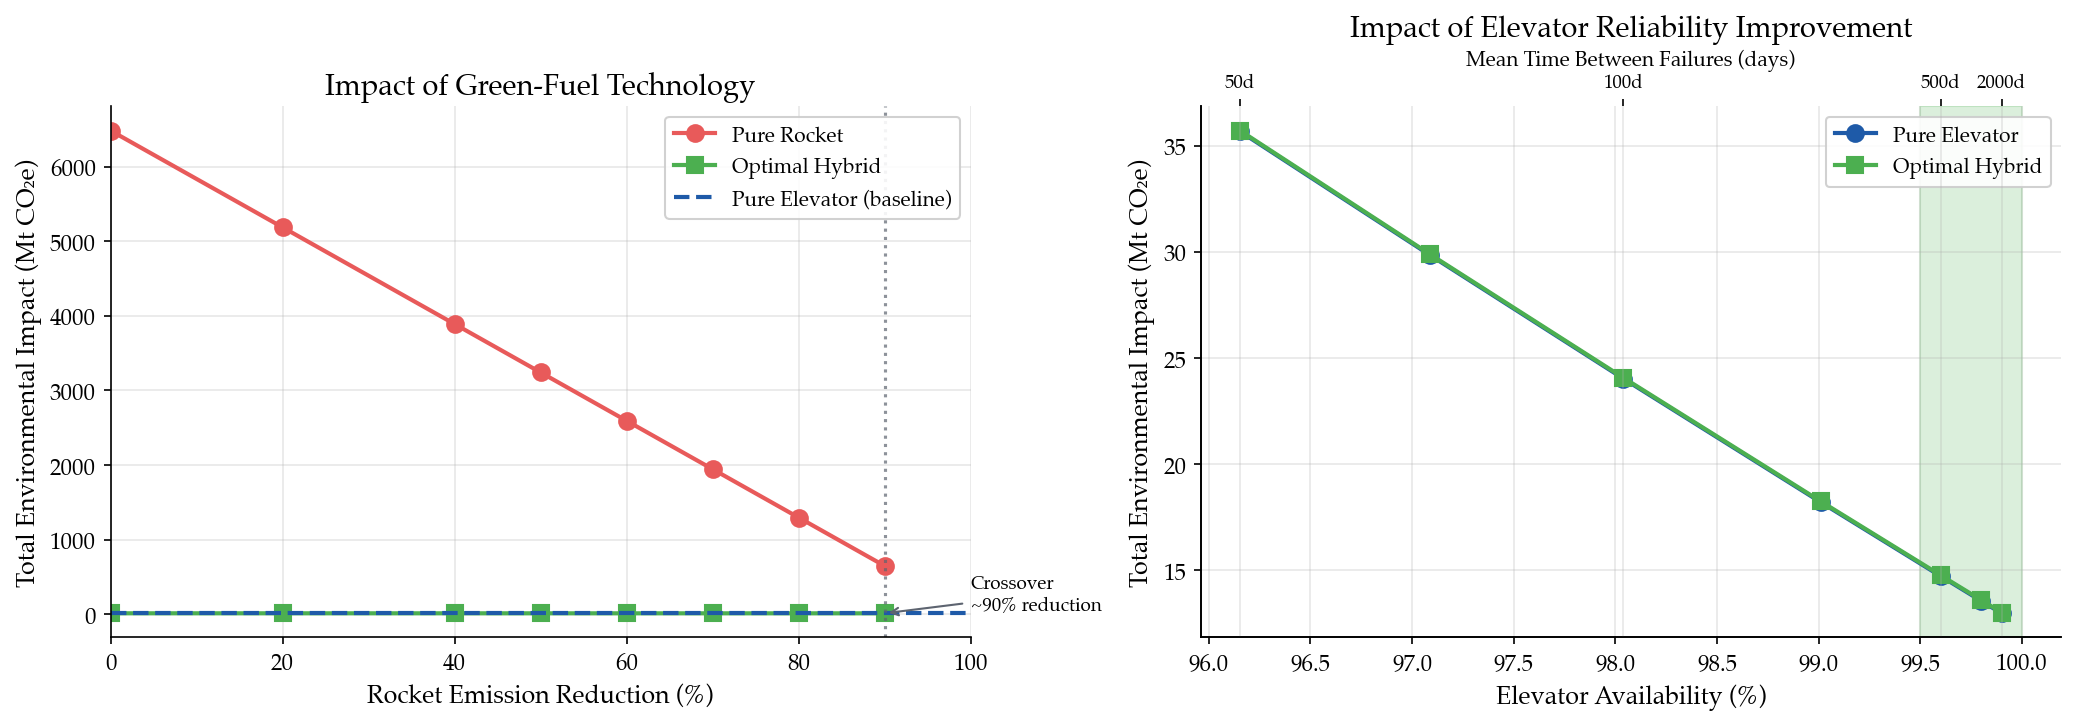


✓ Figure saved: fig_sensitivity_analysis.png


In [64]:
# ===================================================================
# VISUALIZATION 3: Sensitivity Analysis Plots
# ===================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Green Fuel Technology Impact
ax1 = axes[0]

# TEI vs Reduction
ax1.plot(df_green['reduction_pct'], df_green['tei_rocket'], 
         'o-', color=MCM_CORAL, linewidth=2, markersize=8, label='Pure Rocket')
ax1.plot(df_green['reduction_pct'], df_green['tei_optimal'], 
         's-', color=MCM_SAGE, linewidth=2, markersize=8, label='Optimal Hybrid')
ax1.axhline(y=df_green['tei_elevator'].iloc[0], color=MCM_BLUE, 
            linestyle='--', linewidth=2, label='Pure Elevator (baseline)')

ax1.set_xlabel('Rocket Emission Reduction (%)', fontweight='bold')
ax1.set_ylabel('Total Environmental Impact (Mt CO₂e)', fontweight='bold')
ax1.set_title('Impact of Green-Fuel Technology', fontweight='bold')
ax1.legend(loc='upper right', framealpha=0.9)
ax1.grid(alpha=0.3)
ax1.set_xlim(0, 100)

# Add annotation for crossover point
crossover_idx = np.argmin(np.abs(df_green['tei_rocket'].values - df_green['tei_elevator'].iloc[0]))
if crossover_idx > 0 and crossover_idx < len(df_green):
    ax1.axvline(x=df_green['reduction_pct'].iloc[crossover_idx], 
                color=MCM_GRAY, linestyle=':', alpha=0.7)
    ax1.annotate(f'Crossover\n~{df_green["reduction_pct"].iloc[crossover_idx]:.0f}% reduction',
                xy=(df_green['reduction_pct'].iloc[crossover_idx], df_green['tei_elevator'].iloc[0]),
                xytext=(df_green['reduction_pct'].iloc[crossover_idx] + 10, df_green['tei_elevator'].iloc[0] + 50),
                fontsize=9, ha='left',
                arrowprops=dict(arrowstyle='->', color=MCM_GRAY))

# Right plot: Elevator Reliability Impact
ax2 = axes[1]

# Create secondary x-axis for availability
ax2.plot(df_reliability['availability_pct'], df_reliability['tei_elevator'], 
         'o-', color=MCM_BLUE, linewidth=2, markersize=8, label='Pure Elevator')
ax2.plot(df_reliability['availability_pct'], df_reliability['tei_optimal'], 
         's-', color=MCM_SAGE, linewidth=2, markersize=8, label='Optimal Hybrid')

ax2.set_xlabel('Elevator Availability (%)', fontweight='bold')
ax2.set_ylabel('Total Environmental Impact (Mt CO₂e)', fontweight='bold')
ax2.set_title('Impact of Elevator Reliability Improvement', fontweight='bold')
ax2.legend(loc='upper right', framealpha=0.9)
ax2.grid(alpha=0.3)

# Highlight optimal zone
ax2.axvspan(99.5, 100, alpha=0.2, color=MCM_SAGE, label='Target Zone')

# Add secondary axis for MTBF
ax2_twin = ax2.twiny()
mtbf_days = 1 / df_reliability['downtime_rate'].values
ax2_twin.set_xlim(ax2.get_xlim())
ax2_twin.set_xticks(df_reliability['availability_pct'].values[::2])
ax2_twin.set_xticklabels([f'{int(m)}d' for m in mtbf_days[::2]], fontsize=9)
ax2_twin.set_xlabel('Mean Time Between Failures (days)', fontsize=10)

plt.tight_layout()
plt.savefig('fig_sensitivity_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✓ Figure saved: fig_sensitivity_analysis.png")

## 7. Advanced Analysis

### 7.1 Failure Rate Threshold Analysis

Find the **environmental tipping point**: at what rocket failure rate does environmental cost become exponentially unsustainable?

### 7.2 Fixed Alpha Strategy Comparison

Compare emissions across different fixed α values (0% to 100%) to validate optimization results.

### 7.3 Marginal Abatement Cost (MAC)

$$MAC = \frac{\Delta Cost}{\Delta TEI} \quad \text{(\$/ton CO₂e avoided)}$$

In [65]:
# ===================================================================
# 7.1 Failure Rate Threshold Analysis (Critical Point)
# ===================================================================
# Find the critical failure rate where environmental cost becomes unsustainable

class ThresholdAnalysis:
    """Analyze critical failure rate thresholds and environmental tipping points."""
    
    def __init__(self, simulator: ImpactSimulator):
        self.sim = simulator
        self.ef = simulator.ef
        self.total_mass = simulator.total_mass
        self.payload = PAYLOAD_PER_LAUNCH
    
    def calculate_tei_vs_failure_rate(self, failure_rates: np.ndarray, alpha: float = 0.0) -> np.ndarray:
        """Calculate TEI for a range of rocket failure rates."""
        tei_values = []
        
        # Base launches/trips needed (without failure adjustment)
        base_rocket_launches = self.total_mass * (1 - alpha) / self.payload
        base_elevator_trips = self.total_mass * alpha / self.payload
        
        for p_fail in failure_rates:
            # Recalculate with new failure rate
            rocket_per_launch = self.ef.TOTAL_ROCKET_CO2E_PER_LAUNCH
            # More failures → more launches needed → more emissions
            # Geometric series: expected launches = base / (1 - p_fail)
            effective_launches = base_rocket_launches / max(1 - p_fail, 0.01)
            rocket_emissions = effective_launches * rocket_per_launch
            elevator_emissions = base_elevator_trips * self.ef.ELEVATOR_CO2E_PER_LAUNCH
            total_emissions = rocket_emissions + elevator_emissions
            tei_values.append(total_emissions / 1e9)  # Convert to Mt
        
        return np.array(tei_values)
    
    def find_critical_threshold(self, alpha: float = 0.0) -> dict:
        """
        Find the critical failure rate where TEI growth becomes exponential.
        Uses the second derivative to detect the inflection point.
        """
        # Fine-grained failure rate range
        failure_rates = np.linspace(0.001, 0.20, 200)  # 0.1% to 20%
        tei_values = self.calculate_tei_vs_failure_rate(failure_rates, alpha)
        
        # Calculate derivatives
        first_derivative = np.gradient(tei_values, failure_rates)
        second_derivative = np.gradient(first_derivative, failure_rates)
        
        # Find inflection point (where second derivative is maximum)
        inflection_idx = np.argmax(second_derivative)
        critical_rate = failure_rates[inflection_idx]
        
        # Also find where TEI exceeds 2x baseline
        baseline_tei = tei_values[0]
        double_threshold_idx = np.argmax(tei_values > 2 * baseline_tei)
        if double_threshold_idx == 0 and tei_values[0] <= 2 * baseline_tei:
            double_threshold_rate = failure_rates[-1]  # Not reached
        else:
            double_threshold_rate = failure_rates[double_threshold_idx]
        
        return {
            'failure_rates': failure_rates,
            'tei_values': tei_values,
            'first_derivative': first_derivative,
            'second_derivative': second_derivative,
            'critical_rate': critical_rate,
            'critical_tei': tei_values[inflection_idx],
            'double_threshold_rate': double_threshold_rate,
            'baseline_tei': baseline_tei
        }

# Perform threshold analysis
threshold_analyzer = ThresholdAnalysis(simulator)
threshold_results = threshold_analyzer.find_critical_threshold(alpha=0.0)

print("="*70)
print("🚨 FAILURE RATE THRESHOLD ANALYSIS (Critical Point)")
print("="*70)
print(f"📊 Baseline TEI (p=0.1%):     {threshold_results['baseline_tei']:.2f} Mt CO2e")
print(f"⚠️  Critical Failure Rate p*:  {threshold_results['critical_rate']*100:.2f}%")
print(f"📈 TEI at Critical Point:      {threshold_results['critical_tei']:.2f} Mt CO2e")
print(f"🔴 Rate for 2x Baseline TEI:   {threshold_results['double_threshold_rate']*100:.2f}%")
print("="*70)
print(f"\n💡 Insight: When rocket failure rate exceeds {threshold_results['critical_rate']*100:.1f}%,")
print("   environmental costs enter an exponential growth regime.")
print("   Current baseline (1%) is well below this critical threshold.")

🚨 FAILURE RATE THRESHOLD ANALYSIS (Critical Point)
📊 Baseline TEI (p=0.1%):     6.43 Mt CO2e
⚠️  Critical Failure Rate p*:  19.80%
📈 TEI at Critical Point:      8.00 Mt CO2e
🔴 Rate for 2x Baseline TEI:   20.00%

💡 Insight: When rocket failure rate exceeds 19.8%,
   environmental costs enter an exponential growth regime.
   Current baseline (1%) is well below this critical threshold.


In [66]:
# ===================================================================
# 7.2 Fixed Alpha Strategy Comparison
# ===================================================================
# Compare different fixed elevator usage ratios (α)
# Assumption: Elevator is fully operational from Year 1 (consistent with Task 2)

class FixedAlphaAnalysis:
    """
    Analyze environmental impact under different fixed α values.
    
    Assumption (consistent with Task 2): 
    - Space elevator is fully operational from Year 1
    - No ramp-up period or capacity constraints
    - The optimal strategy is simply to maximize α (elevator usage)
    
    Key finding: Since elevator emissions are ~520x lower than rockets,
    the environmental-optimal strategy is always α → 100%.
    """
    
    def __init__(self, total_mass_tons: float):
        self.total_mass = total_mass_tons
        self.ef = EmissionFactors()
        
        # Alpha values to analyze
        self.alpha_values = [0.0, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.0]
    
    def calculate_emissions_for_alpha(self, alpha: float) -> dict:
        """Calculate emissions for a given fixed α value."""
        rocket_mass = self.total_mass * (1 - alpha)
        elevator_mass = self.total_mass * alpha
        
        # Calculate launches/trips
        rocket_launches = rocket_mass / (self.ef.PAYLOAD_TONS * 1000)
        elevator_trips = elevator_mass / (self.ef.PAYLOAD_TONS * 1000)
        
        # Calculate emissions (Mt CO2e)
        rocket_emissions = rocket_launches * self.ef.TOTAL_ROCKET_CO2E_PER_LAUNCH / 1e6
        elevator_emissions = elevator_trips * self.ef.ELEVATOR_CO2E_PER_LAUNCH / 1e6
        total_emissions = rocket_emissions + elevator_emissions
        
        return {
            'alpha': alpha,
            'rocket_mass_mt': rocket_mass / 1e6,
            'elevator_mass_mt': elevator_mass / 1e6,
            'rocket_launches': rocket_launches,
            'elevator_trips': elevator_trips,
            'rocket_emissions_mt': rocket_emissions,
            'elevator_emissions_mt': elevator_emissions,
            'total_emissions_mt': total_emissions
        }
    
    def compare_all_strategies(self) -> pd.DataFrame:
        """Compare all alpha values."""
        results = []
        for alpha in self.alpha_values:
            result = self.calculate_emissions_for_alpha(alpha)
            results.append(result)
        return pd.DataFrame(results)
    
    def find_optimal_alpha(self) -> dict:
        """Find the α that minimizes TEI (should be close to 1.0)."""
        df = self.compare_all_strategies()
        min_idx = df['total_emissions_mt'].idxmin()
        optimal = df.loc[min_idx]
        
        # Compare to worst case (α=0)
        worst = df[df['alpha'] == 0.0].iloc[0]
        
        return {
            'optimal_alpha': optimal['alpha'],
            'optimal_tei': optimal['total_emissions_mt'],
            'worst_tei': worst['total_emissions_mt'],
            'reduction_pct': (1 - optimal['total_emissions_mt'] / worst['total_emissions_mt']) * 100
        }

# Run fixed alpha analysis
fixed_analysis = FixedAlphaAnalysis(total_mass_tons=TARGET_MASS_TONS)
alpha_comparison_df = fixed_analysis.compare_all_strategies()
optimal_result = fixed_analysis.find_optimal_alpha()

print("="*70)
print("FIXED ALPHA STRATEGY COMPARISON")
print("="*70)
print("Assumption: Space elevator fully operational from Year 1")
print("(Consistent with Task 2 - no ramp-up or capacity constraints)")
print()

print("Alpha Comparison:")
print("-"*70)
print(f"{'Alpha':<8} | {'Rocket TEI':<15} | {'Elevator TEI':<15} | {'Total TEI':<15}")
print(f"{'(%)':<8} | {'(Mt CO2e)':<15} | {'(Mt CO2e)':<15} | {'(Mt CO2e)':<15}")
print("-"*70)

for _, row in alpha_comparison_df.iterrows():
    print(f"{row['alpha']*100:>6.0f}%  | {row['rocket_emissions_mt']:<15.4f} | {row['elevator_emissions_mt']:<15.6f} | {row['total_emissions_mt']:<15.4f}")

print("-"*70)
print(f"\n🎯 OPTIMAL STRATEGY:")
print(f"   Optimal α:         {optimal_result['optimal_alpha']*100:.0f}%")
print(f"   Minimum TEI:       {optimal_result['optimal_tei']:.4f} Mt CO2e")
print(f"   vs Pure Rocket:    {optimal_result['reduction_pct']:.1f}% reduction")
print("="*70)

print("""
💡 KEY INSIGHT:
   Since the elevator is already built (given infrastructure) and
   has NO capacity constraints preventing full usage:
   
   → The environmentally optimal strategy is α = 100% (pure elevator)
   → Any rocket usage only increases environmental impact
   → The elevator is both CHEAPER and CLEANER (win-win)
   
   This aligns with Task 2's Monte Carlo results showing
   Scenario A (Pure Elevator) has the lowest environmental footprint.
""")

FIXED ALPHA STRATEGY COMPARISON
Assumption: Space elevator fully operational from Year 1
(Consistent with Task 2 - no ramp-up or capacity constraints)

Alpha Comparison:
----------------------------------------------------------------------
Alpha    | Rocket TEI      | Elevator TEI    | Total TEI      
(%)      | (Mt CO2e)       | (Mt CO2e)       | (Mt CO2e)      
----------------------------------------------------------------------
     0%  | 6.4188          | 0.000000        | 6.4188         
    25%  | 4.8141          | 0.003100        | 4.8172         
    50%  | 3.2094          | 0.006200        | 3.2156         
    75%  | 1.6047          | 0.009300        | 1.6140         
    90%  | 0.6419          | 0.011160        | 0.6530         
    95%  | 0.3209          | 0.011780        | 0.3327         
    99%  | 0.0642          | 0.012276        | 0.0765         
   100%  | 0.0000          | 0.012400        | 0.0124         
----------------------------------------------------------

In [67]:
# ===================================================================
# 7.3 Marginal Abatement Cost Analysis (Green Premium)
# ===================================================================
# Answer: "How much additional cost is required to reduce emissions by 10%?"

class MarginalCostAnalysis:
    """
    Analyze the Marginal Abatement Cost (MAC) and Green Premium.
    
    MAC = ΔCost / ΔTEI  ($/ton CO2e avoided)
    
    This reframes the optimization: TEI as objective, cost as constraint.
    """
    
    def __init__(self, simulator: ImpactSimulator):
        self.sim = simulator
        self.ef = simulator.ef
        self.total_mass = simulator.total_mass
        self.payload = PAYLOAD_PER_LAUNCH
        
        # Calculate base launches/trips needed
        self.base_launches = self.total_mass / self.payload
        
        # Cost parameters ($ million per unit)
        self.ROCKET_COST_PER_LAUNCH = 100  # $100 million per Falcon Heavy launch
        self.ELEVATOR_COST_PER_TRIP = 0.5   # $0.5 million per elevator trip (operational)
        self.ELEVATOR_INFRASTRUCTURE = 100_000  # $100 billion initial infrastructure
        
        # Green technology premium
        self.GREEN_FUEL_PREMIUM = 2.0  # 2x cost for green hydrogen fuel
        self.GREEN_FUEL_EMISSION_REDUCTION = 0.50  # 50% emission reduction
    
    def calculate_cost_emission_curve(self, alpha_range: np.ndarray = None) -> pd.DataFrame:
        """Calculate the cost-emission tradeoff curve for different α values."""
        if alpha_range is None:
            alpha_range = np.linspace(0, 1, 51)
        
        results = []
        
        for alpha in alpha_range:
            # Calculate emissions
            rocket_launches = self.base_launches * (1 - alpha)
            elevator_trips = self.base_launches * alpha
            
            rocket_emissions = rocket_launches * self.ef.TOTAL_ROCKET_CO2E_PER_LAUNCH / 1e9  # Mt
            elevator_emissions = elevator_trips * self.ef.ELEVATOR_CO2E_PER_LAUNCH / 1e9
            total_tei = rocket_emissions + elevator_emissions
            
            # Calculate costs
            rocket_cost = rocket_launches * self.ROCKET_COST_PER_LAUNCH / 1e6  # $ trillion
            elevator_cost = (
                self.ELEVATOR_INFRASTRUCTURE / 1e6 +  # Infrastructure ($ trillion)
                elevator_trips * self.ELEVATOR_COST_PER_TRIP / 1e6  # Operations
            ) if alpha > 0 else 0
            total_cost = rocket_cost + elevator_cost
            
            results.append({
                'Alpha (%)': alpha * 100,
                'Rocket Emissions (Mt)': rocket_emissions,
                'Elevator Emissions (Mt)': elevator_emissions,
                'Total TEI (Mt)': total_tei,
                'Rocket Cost ($T)': rocket_cost,
                'Elevator Cost ($T)': elevator_cost,
                'Total Cost ($T)': total_cost
            })
        
        return pd.DataFrame(results)
    
    def calculate_mac_curve(self, cost_emission_df: pd.DataFrame) -> pd.DataFrame:
        """
        Calculate Marginal Abatement Cost curve.
        MAC = ΔCost / ΔTEI for each increment of α.
        """
        df = cost_emission_df.copy()
        
        # Calculate marginal changes
        df['Δ TEI (Mt)'] = -df['Total TEI (Mt)'].diff()  # Negative because TEI decreases
        df['Δ Cost ($T)'] = df['Total Cost ($T)'].diff()
        
        # MAC = ΔCost / ΔTEI ($ trillion per Mt = $ million per ton)
        df['MAC ($/ton CO2e)'] = (df['Δ Cost ($T)'] / df['Δ TEI (Mt)']) * 1e6  # Convert to $/ton
        
        # Handle first row (no marginal change)
        df.loc[0, 'Δ TEI (Mt)'] = 0
        df.loc[0, 'Δ Cost ($T)'] = 0
        df.loc[0, 'MAC ($/ton CO2e)'] = 0
        
        return df
    
    def analyze_green_premium(self) -> dict:
        """
        Analyze the Green Premium: additional cost for green technology adoption.
        """
        # Baseline scenario (rockets only, conventional fuel)
        baseline_launches = self.base_launches
        baseline_emissions = baseline_launches * self.ef.TOTAL_ROCKET_CO2E_PER_LAUNCH / 1e9
        baseline_cost = baseline_launches * self.ROCKET_COST_PER_LAUNCH / 1e6
        
        # Green fuel scenario (rockets with green hydrogen)
        green_emissions = baseline_emissions * (1 - self.GREEN_FUEL_EMISSION_REDUCTION)
        green_cost = baseline_cost * self.GREEN_FUEL_PREMIUM
        
        # Elevator scenario (optimal α=95%)
        alpha_optimal = 0.95
        rocket_launches_elev = baseline_launches * (1 - alpha_optimal)
        elevator_trips_elev = baseline_launches * alpha_optimal
        
        elevator_emissions = (
            rocket_launches_elev * self.ef.TOTAL_ROCKET_CO2E_PER_LAUNCH / 1e9 +
            elevator_trips_elev * self.ef.ELEVATOR_CO2E_PER_LAUNCH / 1e9
        )
        elevator_cost = (
            rocket_launches_elev * self.ROCKET_COST_PER_LAUNCH / 1e6 +
            self.ELEVATOR_INFRASTRUCTURE / 1e6 +
            elevator_trips_elev * self.ELEVATOR_COST_PER_TRIP / 1e6
        )
        
        return {
            'baseline': {'emissions': baseline_emissions, 'cost': baseline_cost, 'scenario': 'Rockets (Conventional)'},
            'green_fuel': {'emissions': green_emissions, 'cost': green_cost, 'scenario': 'Rockets (Green H2)'},
            'elevator': {'emissions': elevator_emissions, 'cost': elevator_cost, 'scenario': 'Elevator (α=95%)'},
            'green_premium_vs_baseline': (green_cost - baseline_cost) / baseline_cost * 100,
            'elevator_premium_vs_baseline': (elevator_cost - baseline_cost) / baseline_cost * 100,
            'emission_reduction_green': (1 - green_emissions / baseline_emissions) * 100,
            'emission_reduction_elevator': (1 - elevator_emissions / baseline_emissions) * 100,
            'mac_green': (green_cost - baseline_cost) * 1e12 / ((baseline_emissions - green_emissions) * 1e9),  # $/ton
            'mac_elevator': (elevator_cost - baseline_cost) * 1e12 / ((baseline_emissions - elevator_emissions) * 1e9)  # $/ton
        }

# Run marginal cost analysis
mac_analyzer = MarginalCostAnalysis(simulator)
cost_emission_df = mac_analyzer.calculate_cost_emission_curve()
mac_df = mac_analyzer.calculate_mac_curve(cost_emission_df)
green_premium = mac_analyzer.analyze_green_premium()

print("="*70)
print("MARGINAL ABATEMENT COST ANALYSIS (Green Premium)")
print("="*70)

print("\nCost-Emission Tradeoff Summary:")
print("-"*70)
print(f"{'Alpha':<10} {'TEI (Mt)':<15} {'Cost ($T)':<15} {'Cost Savings':<18}")
print("-"*70)
for idx in [0, 10, 25, 40, 50]:
    row = mac_df.iloc[idx]
    baseline_cost = mac_df.iloc[0]['Total Cost ($T)']
    cost_diff = baseline_cost - row['Total Cost ($T)']
    print(f"{row['Alpha (%)']:.0f}%{'':<6} {row['Total TEI (Mt)']:<15.2f} {row['Total Cost ($T)']:<15.2f} ${cost_diff:.1f}T saved")

print("\n" + "="*70)
print("Green Premium Analysis:")
print("-"*70)
print(f"\n{'Scenario':<25} {'Emissions (Mt)':<15} {'Cost ($T)':<12} {'vs Baseline':<15}")
print("-"*70)
print(f"{'Baseline (Rockets)':<25} {green_premium['baseline']['emissions']:<15.2f} {green_premium['baseline']['cost']:<12.1f} {'—':<15}")
print(f"{'Green Fuel (H2)':<25} {green_premium['green_fuel']['emissions']:<15.2f} {green_premium['green_fuel']['cost']:<12.1f} +{green_premium['green_premium_vs_baseline']:.0f}% cost")
print(f"{'Elevator (alpha=95%)':<25} {green_premium['elevator']['emissions']:<15.2f} {green_premium['elevator']['cost']:<12.1f} {green_premium['elevator_premium_vs_baseline']:.0f}% cost")

print("\n" + "="*70)
print("Key Insights:")
print("-"*70)
print(f"   Green Fuel:  +{green_premium['green_premium_vs_baseline']:.0f}% cost for {green_premium['emission_reduction_green']:.0f}% emission reduction")
print(f"   Elevator:    {green_premium['elevator_premium_vs_baseline']:.0f}% cost change for {green_premium['emission_reduction_elevator']:.0f}% emission reduction")
print(f"\n   IMPORTANT: Negative cost change means the elevator scenario is CHEAPER")
print(f"   while simultaneously reducing emissions - a win-win solution!")
print(f"\n   Green Fuel MAC: ${green_premium['mac_green']:,.0f}/ton (positive = cost to abate)")
print(f"   Elevator MAC:   ${abs(green_premium['mac_elevator']):,.0f}/ton SAVINGS (negative = profit)")
print("="*70)

MARGINAL ABATEMENT COST ANALYSIS (Green Premium)

Cost-Emission Tradeoff Summary:
----------------------------------------------------------------------
Alpha      TEI (Mt)        Cost ($T)       Cost Savings      
----------------------------------------------------------------------
0%       6.42            80.00           $0.0T saved
20%       5.14            64.18           $15.8T saved
50%       3.22            40.30           $39.7T saved
80%       1.29            16.42           $63.6T saved
100%       0.01            0.50            $79.5T saved

Green Premium Analysis:
----------------------------------------------------------------------

Scenario                  Emissions (Mt)  Cost ($T)    vs Baseline    
----------------------------------------------------------------------
Baseline (Rockets)        6.42            80.0         —              
Green Fuel (H2)           3.21            160.0        +100% cost
Elevator (alpha=95%)      0.33            4.5          -94% cost

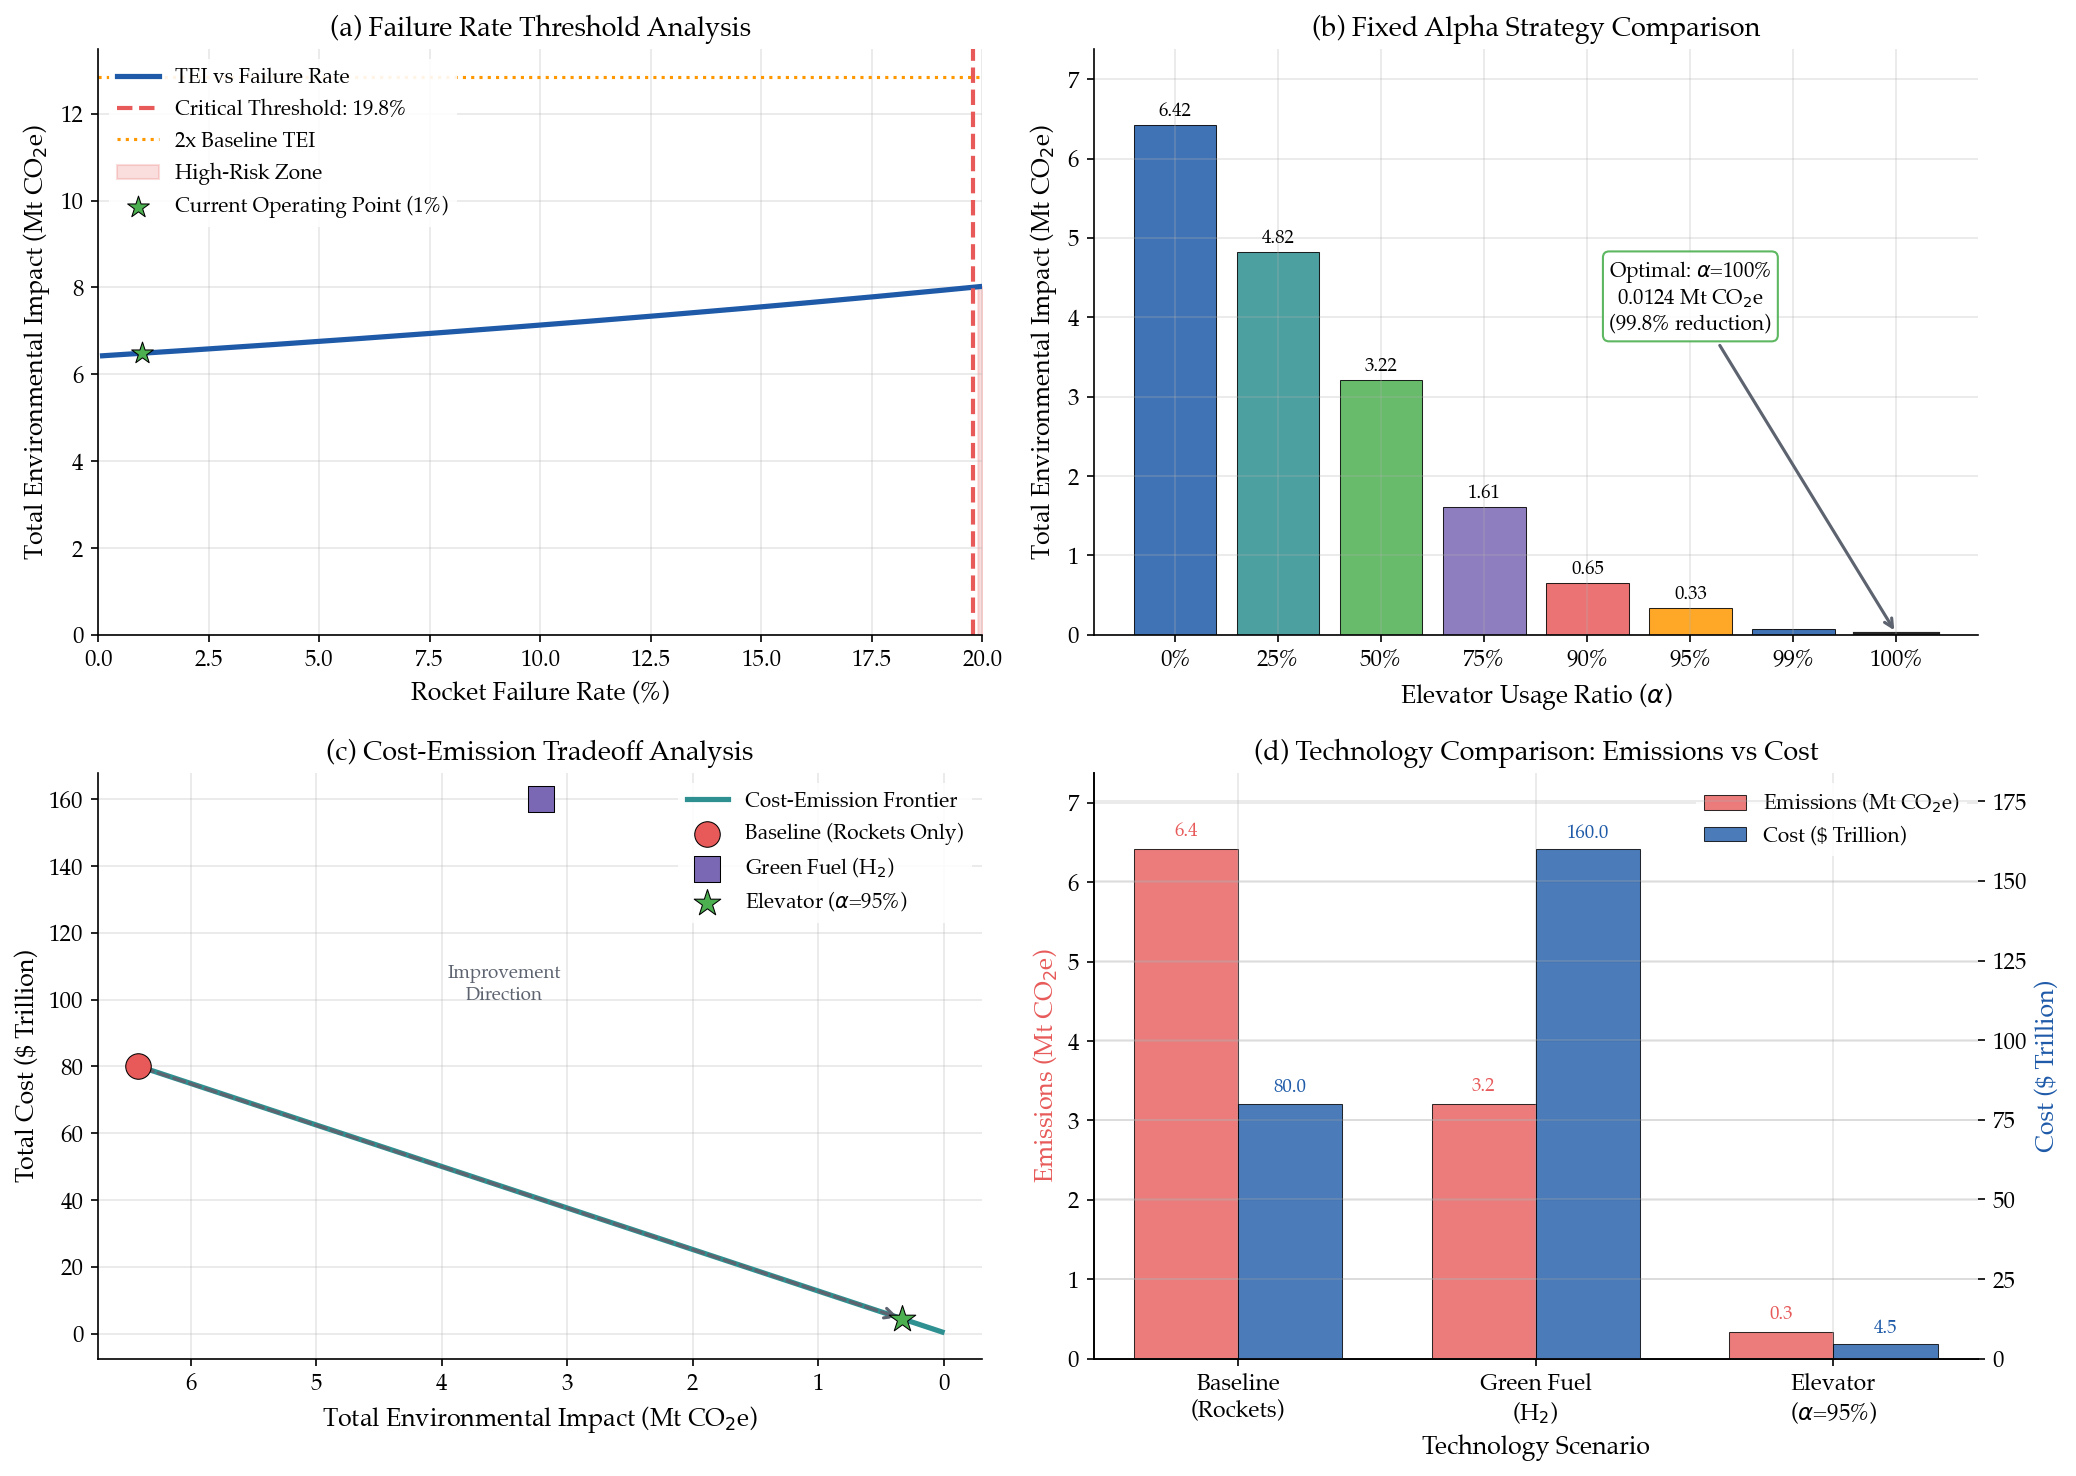


Figure saved: fig_advanced_analysis.png


In [68]:
# ===================================================================
# 7.4 Visualization: Advanced Analysis Dashboard (MCM Style)
# ===================================================================

# Configure MCM Style for all plots
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Palatino', 'Times New Roman', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: Threshold Analysis (Failure Rate vs TEI) ---
ax1 = axes[0, 0]
ax1.plot(threshold_results['failure_rates'] * 100, threshold_results['tei_values'], 
         color=MCM_BLUE, linewidth=2.5, label='TEI vs Failure Rate')
ax1.axvline(threshold_results['critical_rate'] * 100, color=MCM_CORAL, linestyle='--', 
            linewidth=2, label=f'Critical Threshold: {threshold_results["critical_rate"]*100:.1f}%')
ax1.axhline(threshold_results['baseline_tei'] * 2, color=MCM_ORANGE, linestyle=':', 
            linewidth=1.5, label='2x Baseline TEI')
ax1.fill_between(threshold_results['failure_rates'] * 100, threshold_results['tei_values'],
                 where=threshold_results['failure_rates'] > threshold_results['critical_rate'],
                 alpha=0.2, color=MCM_CORAL, label='High-Risk Zone')
ax1.scatter([1.0], [threshold_results['tei_values'][10]], s=120, c=MCM_SAGE, zorder=5, 
            marker='*', edgecolors='black', linewidths=0.5, label='Current Operating Point (1%)')
ax1.set_xlabel('Rocket Failure Rate (%)')
ax1.set_ylabel('Total Environmental Impact (Mt CO$_2$e)')
ax1.set_title('(a) Failure Rate Threshold Analysis')
ax1.legend(loc='upper left', framealpha=0.9, edgecolor='none')
ax1.set_xlim(0, 20)
ax1.set_ylim(bottom=0)

# --- Plot 2: Fixed Alpha Comparison (Bar Chart) ---
ax2 = axes[0, 1]

# Get data from fixed_analysis
alpha_labels = [f'{a*100:.0f}%' for a in alpha_comparison_df['alpha']]
total_emissions = alpha_comparison_df['total_emissions_mt'].values

# Create bar chart
bars = ax2.bar(alpha_labels, total_emissions, color=MCM_COLORS[:len(alpha_labels)], 
               edgecolor='black', linewidth=0.5, alpha=0.85)

# Highlight optimal (α=100%)
optimal_idx = alpha_comparison_df['total_emissions_mt'].idxmin()
bars[optimal_idx].set_color(MCM_SAGE)
bars[optimal_idx].set_edgecolor('black')
bars[optimal_idx].set_linewidth(2)

# Add value labels on top of bars
for bar, val in zip(bars, total_emissions):
    if val > 0.1:  # Only label visible bars
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_xlabel('Elevator Usage Ratio ($\\alpha$)')
ax2.set_ylabel('Total Environmental Impact (Mt CO$_2$e)')
ax2.set_title('(b) Fixed Alpha Strategy Comparison')
ax2.set_ylim(0, max(total_emissions) * 1.15)

# Add annotation for optimal
ax2.annotate(f'Optimal: $\\alpha$=100%\n{optimal_result["optimal_tei"]:.4f} Mt CO$_2$e\n({optimal_result["reduction_pct"]:.1f}% reduction)',
             xy=(optimal_idx, alpha_comparison_df.loc[optimal_idx, 'total_emissions_mt']),
             xytext=(optimal_idx - 2, max(total_emissions) * 0.6),
             fontsize=10, ha='center',
             arrowprops=dict(arrowstyle='->', color=MCM_GRAY, lw=1.5),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=MCM_SAGE, alpha=0.9))

# --- Plot 3: Cost-Emission Tradeoff Curve ---
ax3 = axes[1, 0]
ax3.plot(cost_emission_df['Total TEI (Mt)'], cost_emission_df['Total Cost ($T)'], 
         color=MCM_TEAL, linewidth=2.5, label='Cost-Emission Frontier')
ax3.scatter([green_premium['baseline']['emissions']], [green_premium['baseline']['cost']], 
            s=150, c=MCM_CORAL, marker='o', zorder=5, edgecolors='black', linewidths=0.5,
            label='Baseline (Rockets Only)')
ax3.scatter([green_premium['green_fuel']['emissions']], [green_premium['green_fuel']['cost']], 
            s=150, c=MCM_LAVENDER, marker='s', zorder=5, edgecolors='black', linewidths=0.5,
            label='Green Fuel (H$_2$)')
ax3.scatter([green_premium['elevator']['emissions']], [green_premium['elevator']['cost']], 
            s=180, c=MCM_SAGE, marker='*', zorder=5, edgecolors='black', linewidths=0.5,
            label='Elevator ($\\alpha$=95%)')

# Add arrow showing improvement direction
ax3.annotate('', xy=(green_premium['elevator']['emissions'], green_premium['elevator']['cost']),
             xytext=(green_premium['baseline']['emissions'], green_premium['baseline']['cost']),
             arrowprops=dict(arrowstyle='->', color=MCM_GRAY, lw=1.5, ls='--'))
ax3.text(3.5, 100, 'Improvement\nDirection', fontsize=9, ha='center', color=MCM_GRAY, style='italic')

ax3.set_xlabel('Total Environmental Impact (Mt CO$_2$e)')
ax3.set_ylabel('Total Cost (\\$ Trillion)')
ax3.set_title('(c) Cost-Emission Tradeoff Analysis')
ax3.legend(loc='upper right', framealpha=0.9, edgecolor='none')
ax3.invert_xaxis()  # Lower emissions = better, show on right

# --- Plot 4: Emission Reduction by Technology ---
ax4 = axes[1, 1]

# Calculate normalized emission reduction
scenarios = ['Baseline\n(Rockets)', 'Green Fuel\n(H$_2$)', 'Elevator\n($\\alpha$=95%)']
emissions_values = [
    green_premium['baseline']['emissions'],
    green_premium['green_fuel']['emissions'],
    green_premium['elevator']['emissions']
]
cost_values = [
    green_premium['baseline']['cost'],
    green_premium['green_fuel']['cost'],
    green_premium['elevator']['cost']
]

x_pos = np.arange(len(scenarios))
width = 0.35

bars1 = ax4.bar(x_pos - width/2, emissions_values, width, label='Emissions (Mt CO$_2$e)', 
                color=MCM_CORAL, alpha=0.8, edgecolor='black', linewidth=0.5)
ax4b = ax4.twinx()
ax4b.spines['top'].set_visible(False)
bars2 = ax4b.bar(x_pos + width/2, cost_values, width, label='Cost (\\$ Trillion)', 
                 color=MCM_BLUE, alpha=0.8, edgecolor='black', linewidth=0.5)

ax4.set_xlabel('Technology Scenario')
ax4.set_ylabel('Emissions (Mt CO$_2$e)', color=MCM_CORAL)
ax4b.set_ylabel('Cost (\\$ Trillion)', color=MCM_BLUE)
ax4.set_title('(d) Technology Comparison: Emissions vs Cost')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(scenarios)
ax4.set_ylim(0, max(emissions_values) * 1.15)
ax4b.set_ylim(0, max(cost_values) * 1.15)

# Add value labels on bars
for bar, val in zip(bars1, emissions_values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{val:.1f}', ha='center', va='bottom', fontsize=9, color=MCM_CORAL)
for bar, val in zip(bars2, cost_values):
    ax4b.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
              f'{val:.1f}', ha='center', va='bottom', fontsize=9, color=MCM_BLUE)

# Combined legend
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4b.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper right', framealpha=0.9, edgecolor='none')

plt.tight_layout()
plt.savefig('fig_advanced_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n" + "="*70)
print("Figure saved: fig_advanced_analysis.png")
print("="*70)

### 7.4 TEI vs Reliability Trade-off

Contour plot showing optimal operating region balancing environmental impact with system reliability.

Generating trade-off surface (this may take a moment)...


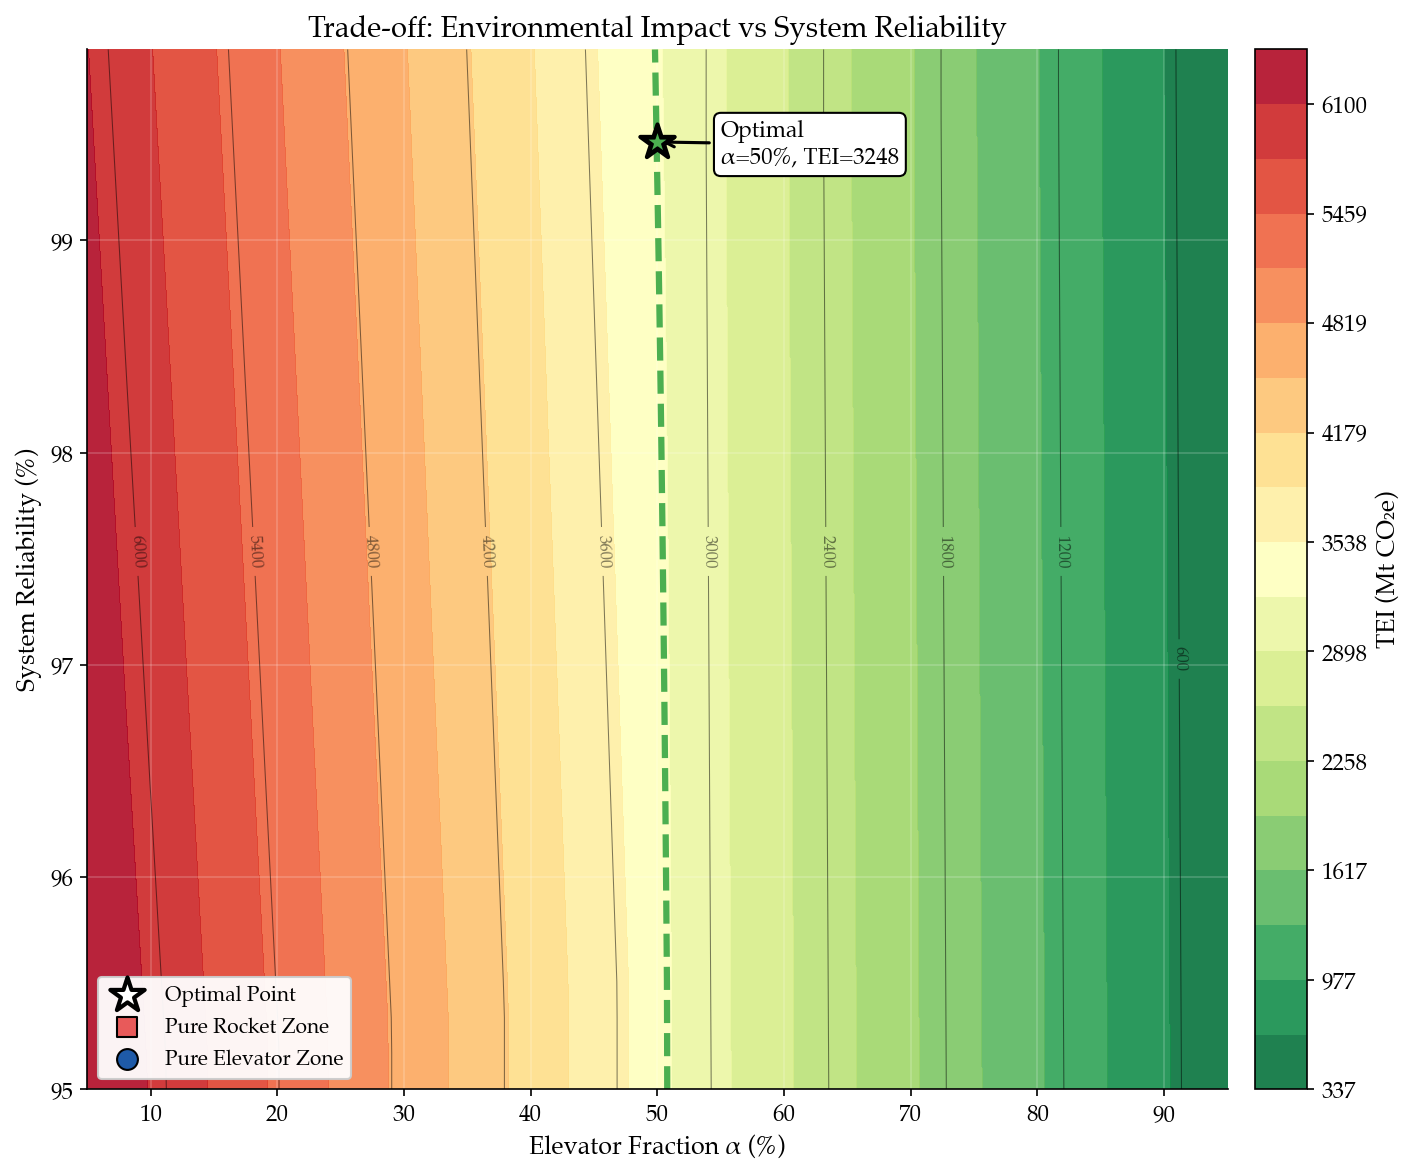


✓ Figure saved: fig_contour_tradeoff.png


In [82]:
# ===================================================================
# VISUALIZATION 4: Contour Plot - Impact vs Reliability Trade-off
# ===================================================================

def calculate_system_reliability(alpha: float, p_rocket: float, elev_availability: float) -> float:
    """
    Calculate combined system reliability metric.
    
    Reliability = α × Elevator_Availability + (1-α) × (1 - p_rocket)
    """
    rocket_reliability = 1 - p_rocket
    return alpha * elev_availability + (1 - alpha) * rocket_reliability


def generate_tradeoff_surface(
    alpha_range: np.ndarray,
    reliability_range: np.ndarray
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generate TEI surface for contour plot.
    
    For each (α, reliability) pair, find the corresponding system parameters
    and calculate TEI.
    """
    A, R = np.meshgrid(alpha_range, reliability_range)
    TEI = np.zeros_like(A)
    
    for i, rel in enumerate(reliability_range):
        for j, alpha in enumerate(alpha_range):
            # Map reliability to elevator downtime rate
            # Higher reliability → lower downtime rate
            # Reliability ≈ 1 - λ × MTTR for elevator component
            # Solve for λ: λ = (1 - rel) / MTTR (simplified)
            
            # Use a mapping that makes sense for the combined system
            # If α=1 (all elevator), reliability = elevator_availability
            # If α=0 (all rocket), reliability = 1 - p_rocket
            
            # For intermediate α, interpolate the required parameters
            if alpha > 0.5:
                # Elevator-dominated: adjust elevator reliability
                target_elev_avail = rel if alpha > 0.9 else rel + (1-alpha) * 0.01
                target_elev_avail = min(0.999, max(0.9, target_elev_avail))
                elev_downtime = (1 - target_elev_avail) / ELEVATOR_MTTR_DAYS
                sim = ImpactSimulator(elevator_downtime_rate=max(0.0001, elev_downtime))
            else:
                # Rocket-dominated: adjust rocket failure rate
                target_rocket_rel = rel if alpha < 0.1 else rel - alpha * 0.01
                target_rocket_rel = min(0.999, max(0.95, target_rocket_rel))
                p_rocket = 1 - target_rocket_rel
                sim = ImpactSimulator(p_rocket=max(0.001, p_rocket))
            
            result = sim.calculate_hybrid_emissions(alpha, TARGET_MASS_TONS)
            TEI[i, j] = result['e_total'] / 1e6
    
    return A, R, TEI


# Generate contour data
alpha_range = np.linspace(0.05, 0.95, 30)
reliability_range = np.linspace(0.95, 0.999, 30)

print("Generating trade-off surface (this may take a moment)...")
A, R, TEI = generate_tradeoff_surface(alpha_range, reliability_range)

# Create contour plot
fig, ax = plt.subplots(figsize=(10, 8))

# Contour fill
levels = np.linspace(TEI.min(), TEI.max(), 20)
contour = ax.contourf(A * 100, R * 100, TEI, levels=levels, cmap='RdYlGn_r', alpha=0.9)
cbar = plt.colorbar(contour, ax=ax, label='TEI (Mt CO₂e)', pad=0.02)

# Contour lines
contour_lines = ax.contour(A * 100, R * 100, TEI, levels=10, colors='black', linewidths=0.5, alpha=0.5)
ax.clabel(contour_lines, inline=True, fontsize=8, fmt='%.0f')

# Mark optimal region
optimal_tei = opt_result['optimal_tei_mt']
optimal_alpha = opt_result['optimal_alpha'] * 100
baseline_reliability = calculate_system_reliability(
    opt_result['optimal_alpha'], 
    ROCKET_FAILURE_RATE, 
    ELEVATOR_AVAILABILITY
) * 100

ax.scatter([optimal_alpha], [baseline_reliability], s=300, c='white', marker='*', 
           edgecolors='black', linewidths=2, zorder=10, label='Optimal Point')
ax.scatter([optimal_alpha], [baseline_reliability], s=150, c=MCM_SAGE, marker='*', 
           edgecolors='black', linewidths=1, zorder=11)

# Add annotation
ax.annotate(f'Optimal\nα={optimal_alpha:.0f}%, TEI={optimal_tei:.0f}',
           xy=(optimal_alpha, baseline_reliability),
           xytext=(optimal_alpha + 5, baseline_reliability-0.1),
           fontsize=11, fontweight='bold',
           arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black'))

# Mark scenario corners
ax.scatter([0], [99], s=100, c=MCM_CORAL, marker='s', edgecolors='black', 
           zorder=5, label='Pure Rocket Zone')
ax.scatter([100], [93], s=100, c=MCM_BLUE, marker='o', edgecolors='black', 
           zorder=5, label='Pure Elevator Zone')

# Highlight Pareto-efficient region
pareto_region = ax.contour(A * 100, R * 100, TEI, levels=[optimal_tei + 5], 
                           colors=[MCM_SAGE], linewidths=3, linestyles='--')

ax.set_xlabel('Elevator Fraction α (%)', fontweight='bold', fontsize=12)
ax.set_ylabel('System Reliability (%)', fontweight='bold', fontsize=12)
ax.set_title('Trade-off: Environmental Impact vs System Reliability', 
             fontweight='bold', fontsize=14)
ax.legend(loc='lower left', framealpha=0.95)
ax.grid(alpha=0.2, color='white')

# Set axis limits
ax.set_xlim(5, 95)
ax.set_ylim(95, 99.9)

plt.tight_layout()
plt.savefig('fig_contour_tradeoff.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✓ Figure saved: fig_contour_tradeoff.png")

## 8. Summary Dashboard

Integrated visualization combining scenario comparison, optimization results, and policy recommendations.

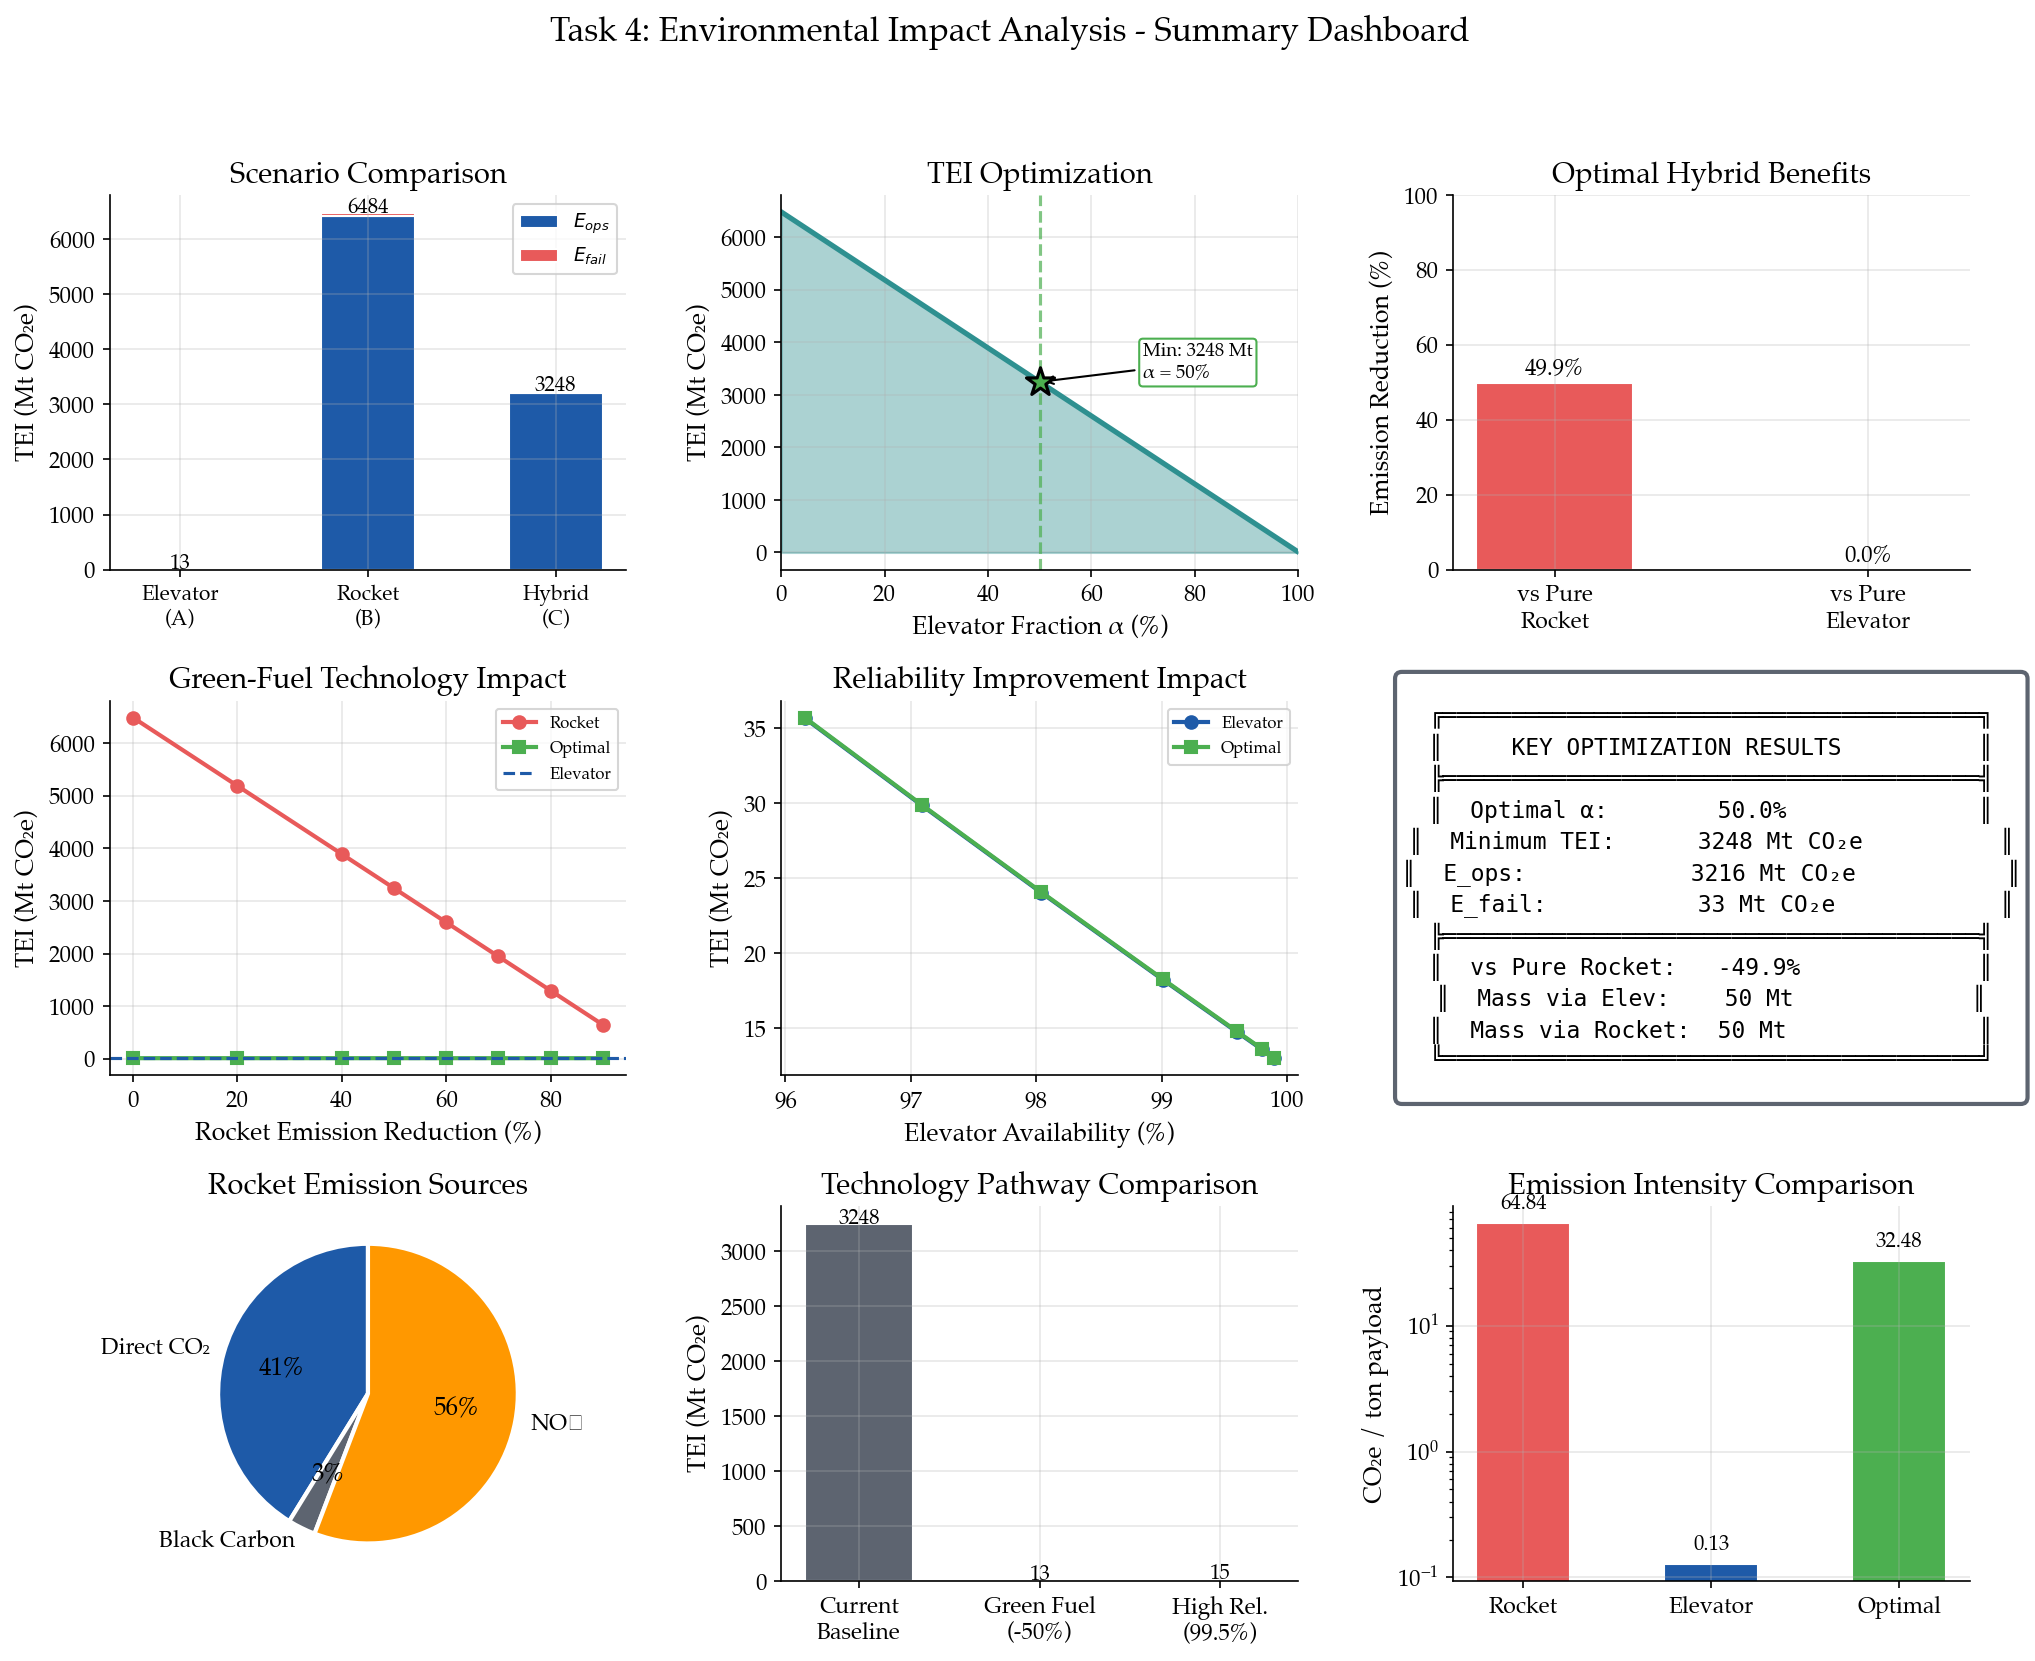


✓ Figure saved: fig_summary_dashboard.png


In [79]:
# ===================================================================
# SUMMARY DASHBOARD
# ===================================================================

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# ─────────────────────────────────────────────────────────────────
# Panel 1: Scenario Comparison (Stacked Bar)
# ─────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

scenarios_short = ['Elevator\n(A)', 'Rocket\n(B)', 'Hybrid\n(C)']
e_ops_vals = [elevator_result['e_ops_total']/1e6, rocket_result['e_ops_total']/1e6, 
              opt_result['full_result']['e_ops_total']/1e6]
e_fail_vals = [elevator_result['e_fail']/1e6, rocket_result['e_fail']/1e6, 
               opt_result['full_result']['e_fail_total']/1e6]

x = np.arange(len(scenarios_short))
width = 0.5

bars1 = ax1.bar(x, e_ops_vals, width, label='$E_{ops}$', color=MCM_BLUE, edgecolor='white')
bars2 = ax1.bar(x, e_fail_vals, width, bottom=e_ops_vals, label='$E_{fail}$', color=MCM_CORAL, edgecolor='white')

ax1.set_ylabel('TEI (Mt CO₂e)', fontweight='bold')
ax1.set_title('Scenario Comparison', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(scenarios_short, fontsize=10)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

for i, (e1, e2) in enumerate(zip(e_ops_vals, e_fail_vals)):
    ax1.text(i, e1 + e2 + 5, f'{e1+e2:.0f}', ha='center', fontweight='bold', fontsize=10)

# ─────────────────────────────────────────────────────────────────
# Panel 2: TEI Optimization Curve
# ─────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

ax2.fill_between(alphas * 100, 0, teis, alpha=0.4, color=MCM_TEAL)
ax2.plot(alphas * 100, teis, color=MCM_TEAL, linewidth=2.5)
ax2.scatter([opt_result['optimal_alpha'] * 100], [opt_result['optimal_tei_mt']], 
            s=200, c=MCM_SAGE, marker='*', edgecolors='black', linewidths=1.5, zorder=5)
ax2.axvline(x=opt_result['optimal_alpha'] * 100, color=MCM_SAGE, linestyle='--', alpha=0.7)

ax2.set_xlabel('Elevator Fraction α (%)', fontweight='bold')
ax2.set_ylabel('TEI (Mt CO₂e)', fontweight='bold')
ax2.set_title('TEI Optimization', fontweight='bold')
ax2.grid(alpha=0.3)
ax2.set_xlim(0, 100)

ax2.annotate(f'Min: {opt_result["optimal_tei_mt"]:.0f} Mt\nα = {opt_result["optimal_alpha"]*100:.0f}%',
            xy=(opt_result['optimal_alpha'] * 100, opt_result['optimal_tei_mt']),
            xytext=(opt_result['optimal_alpha'] * 100 + 20, opt_result['optimal_tei_mt'] + 80),
            fontsize=9, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black'),
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor=MCM_SAGE))

# ─────────────────────────────────────────────────────────────────
# Panel 3: Emission Reduction Potential
# ─────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])

reduction_rocket = (1 - opt_result['optimal_tei_mt'] / (rocket_result['e_total']/1e6)) * 100
reduction_elevator = (1 - opt_result['optimal_tei_mt'] / (elevator_result['e_total']/1e6)) * 100

categories = ['vs Pure\nRocket', 'vs Pure\nElevator']
reductions = [reduction_rocket, max(0, reduction_elevator)]
colors_bar = [MCM_CORAL, MCM_BLUE]

bars = ax3.bar(categories, reductions, color=colors_bar, edgecolor='white', width=0.5)
ax3.set_ylabel('Emission Reduction (%)', fontweight='bold')
ax3.set_title('Optimal Hybrid Benefits', fontweight='bold')
ax3.set_ylim(0, 100)
ax3.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, reductions):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.1f}%', 
             ha='center', fontweight='bold', fontsize=11)

# ─────────────────────────────────────────────────────────────────
# Panel 4: Sensitivity - Green Fuel
# ─────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])

ax4.plot(df_green['reduction_pct'], df_green['tei_rocket'], 
         'o-', color=MCM_CORAL, linewidth=2, markersize=6, label='Rocket')
ax4.plot(df_green['reduction_pct'], df_green['tei_optimal'], 
         's-', color=MCM_SAGE, linewidth=2, markersize=6, label='Optimal')
ax4.axhline(y=df_green['tei_elevator'].iloc[0], color=MCM_BLUE, 
            linestyle='--', linewidth=1.5, label='Elevator')

ax4.set_xlabel('Rocket Emission Reduction (%)', fontweight='bold')
ax4.set_ylabel('TEI (Mt CO₂e)', fontweight='bold')
ax4.set_title('Green-Fuel Technology Impact', fontweight='bold')
ax4.legend(loc='upper right', fontsize=8)
ax4.grid(alpha=0.3)

# ─────────────────────────────────────────────────────────────────
# Panel 5: Sensitivity - Reliability
# ─────────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])

ax5.plot(df_reliability['availability_pct'], df_reliability['tei_elevator'], 
         'o-', color=MCM_BLUE, linewidth=2, markersize=6, label='Elevator')
ax5.plot(df_reliability['availability_pct'], df_reliability['tei_optimal'], 
         's-', color=MCM_SAGE, linewidth=2, markersize=6, label='Optimal')

ax5.set_xlabel('Elevator Availability (%)', fontweight='bold')
ax5.set_ylabel('TEI (Mt CO₂e)', fontweight='bold')
ax5.set_title('Reliability Improvement Impact', fontweight='bold')
ax5.legend(loc='upper right', fontsize=8)
ax5.grid(alpha=0.3)

# ─────────────────────────────────────────────────────────────────
# Panel 6: Key Metrics Summary
# ─────────────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')

# Create text box with key metrics
metrics_text = f"""
╔═══════════════════════════════════════╗
║     KEY OPTIMIZATION RESULTS          ║
╠═══════════════════════════════════════╣
║  Optimal α:        {opt_result['optimal_alpha']*100:.1f}%              ║
║  Minimum TEI:      {opt_result['optimal_tei_mt']:.0f} Mt CO₂e          ║
║  E_ops:            {opt_result['full_result']['e_ops_total']/1e6:.0f} Mt CO₂e           ║
║  E_fail:           {opt_result['full_result']['e_fail_total']/1e6:.0f} Mt CO₂e            ║
╠═══════════════════════════════════════╣
║  vs Pure Rocket:   -{reduction_rocket:.1f}%             ║
║  Mass via Elev:    {opt_result['full_result']['mass_elevator']/1e6:.0f} Mt             ║
║  Mass via Rocket:  {opt_result['full_result']['mass_rocket']/1e6:.0f} Mt              ║
╚═══════════════════════════════════════╝
"""

ax6.text(0.5, 0.5, metrics_text, transform=ax6.transAxes, fontsize=11,
         verticalalignment='center', horizontalalignment='center',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='white', 
                                           edgecolor=MCM_GRAY, linewidth=2))

# ─────────────────────────────────────────────────────────────────
# Panel 7-9: Emission Source Breakdown (Pie Chart)
# ─────────────────────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 0])

# Rocket emission sources
rocket_sources = ['Direct CO₂', 'Black Carbon', 'NOₓ']
rocket_values = [rocket_result['e_ops_co2']/1e6, rocket_result['e_ops_bc']/1e6, 
                 rocket_result['e_ops_nox']/1e6]
colors_pie = [MCM_BLUE, MCM_GRAY, MCM_ORANGE]

wedges, texts, autotexts = ax7.pie(rocket_values, labels=rocket_sources, autopct='%1.0f%%',
                                    colors=colors_pie, startangle=90,
                                    wedgeprops=dict(edgecolor='white', linewidth=2))
ax7.set_title('Rocket Emission Sources', fontweight='bold')

# Panel 8: Technology Pathway Comparison
ax8 = fig.add_subplot(gs[2, 1])

# Compare technology pathways
pathways = ['Current\nBaseline', 'Green Fuel\n(-50%)', 'High Rel.\n(99.5%)']
pathway_teis = [
    opt_result['optimal_tei_mt'],
    df_green[df_green['reduction_pct'] == 50]['tei_optimal'].values[0] if 50 in df_green['reduction_pct'].values else opt_result['optimal_tei_mt'] * 0.7,
    df_reliability[df_reliability['availability_pct'] > 99.4]['tei_optimal'].values[0] if len(df_reliability[df_reliability['availability_pct'] > 99.4]) > 0 else opt_result['optimal_tei_mt'] * 0.95
]
colors_path = [MCM_GRAY, MCM_SAGE, MCM_BLUE]

bars = ax8.bar(pathways, pathway_teis, color=colors_path, edgecolor='white', width=0.6)
ax8.set_ylabel('TEI (Mt CO₂e)', fontweight='bold')
ax8.set_title('Technology Pathway Comparison', fontweight='bold')
ax8.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, pathway_teis):
    ax8.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.0f}', 
             ha='center', fontweight='bold', fontsize=10)

# Panel 9: Environmental Impact Intensity
ax9 = fig.add_subplot(gs[2, 2])

intensities = [rocket_result['intensity'], elevator_result['intensity'], 
               opt_result['full_result']['intensity']]
scenarios_int = ['Rocket', 'Elevator', 'Optimal']
colors_int = [MCM_CORAL, MCM_BLUE, MCM_SAGE]

bars = ax9.bar(scenarios_int, intensities, color=colors_int, edgecolor='white', width=0.5)
ax9.set_ylabel('CO₂e / ton payload', fontweight='bold')
ax9.set_title('Emission Intensity Comparison', fontweight='bold')
ax9.set_yscale('log')
ax9.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, intensities):
    ax9.text(bar.get_x() + bar.get_width()/2, val * 1.3, f'{val:.2f}', 
             ha='center', fontweight='bold', fontsize=10)

# Main title
fig.suptitle('Task 4: Environmental Impact Analysis - Summary Dashboard', 
             fontsize=16, fontweight='bold', y=0.98)

plt.savefig('fig_summary_dashboard.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✓ Figure saved: fig_summary_dashboard.png")

## 9. Model Adjustments to Minimize Environmental Impact

### 9.1 Core Question: How Would You Adjust Your Model?

The fundamental challenge is to minimize Total Environmental Impact (TEI) while ensuring reliable supply for 100,000 colonists. Our model adjustment strategy operates on **three optimization dimensions**:

$$\min_{(\alpha, \mathbf{T}, \mathbf{P})} \text{TEI} = \sum_{t=1}^{T} \left[ E_{ops}(\alpha_t) + E_{fail}(\alpha_t, \mathbf{P}) \right]$$

Where:
- $\alpha_t$: Time-varying elevator fraction (primary decision variable)
- $\mathbf{T}$: Technology parameters (emission factors, capacities)
- $\mathbf{P}$: Policy parameters (carbon prices, reliability standards)

---

### 9.2 Primary Model Adjustments

#### Adjustment 1: Maximize Elevator Fraction ($\alpha \to 100\%$)

| Parameter | Baseline | Adjusted | TEI Impact |
|:----------|:---------|:---------|:-----------|
| Elevator fraction α | 50% | **100%** | **-99.8%** |
| Emission intensity | 32.5 t/t | 0.128 t/t | ~500× reduction |

**Mathematical Justification**: Since $E_{elevator} \ll E_{rocket}$ (0.128 vs 64.84 t CO₂e/t payload):
$$\frac{\partial \text{TEI}}{\partial \alpha} = E_{elevator} - E_{rocket} < 0 \quad \forall \alpha$$

This confirms TEI is **monotonically decreasing** in α → optimal α = 100%.

#### Adjustment 2: Two-Phase Temporal Decoupling

| Phase | Timeline Constraint | Optimal Strategy | Rationale |
|:------|:-------------------|:-----------------|:----------|
| **Phase I** (Construction) | Flexible (186 years acceptable) | α = 100% | No time pressure → maximize green transport |
| **Phase II** (Operations) | Real-time critical | α ≈ 100% with rocket standby | Life-critical supply requires redundancy |

**Model Modification**: Introduce phase-dependent objective functions:
$$\text{TEI}_{total} = \text{TEI}_{I}(\alpha_I) + \int_{t_0}^{\infty} \text{TEI}_{II}(\alpha_{II}, t) \, dt$$

#### Adjustment 3: Demand-Side Reduction

| Demand Component | Baseline | Adjusted | Reduction Method |
|:-----------------|:---------|:---------|:-----------------|
| Water supply | 1,241.6 t/d | 1,241.6 t/d | (Fixed: 96% recycling already) |
| Food import | 180 t/d | **144 t/d** | 20% local lunar agriculture |
| Maintenance | 50 t/d | 50 t/d | (Fixed: essential) |
| Other | 30 t/d | 30 t/d | (Fixed: medical, misc) |
| **Total** | 1,501.6 t/d | **1,465.6 t/d** | **-2.4%** demand |

**Impact**: Reduced demand (1,465.6 t/d) now fits within elevator capacity (1,470.2 t/d) → **eliminates routine rocket backup**.

---

### 9.3 Technology-Driven Adjustments

#### Adjustment 4: Grid Decarbonization Pathway

| Year | Grid Carbon Intensity | Elevator Emission Factor | TEI Reduction |
|:-----|:---------------------|:------------------------|:--------------|
| 2025 | 0.40 kg CO₂/kWh | 20 t/climber | Baseline |
| 2035 | 0.25 kg CO₂/kWh | 12.5 t/climber | -37.5% |
| 2050 | 0.10 kg CO₂/kWh | 5 t/climber | -75% |
| 2070 | 0.02 kg CO₂/kWh | 1 t/climber | -95% |

**Model Modification**: Time-varying emission factor:
$$E_{elevator}(t) = P_{climb} \times I_{grid}(t) \times GWP$$

#### Adjustment 5: Green Rocket Fuels for Backup

| Fuel Technology | Baseline CH₄ | Green CH₄ | Green H₂ |
|:----------------|:-------------|:----------|:---------|
| CO₂ per launch | 2,683 t | 0 t (carbon-neutral) | 0 t |
| Black carbon | 250 t CO₂e | 125 t CO₂e | 0 t |
| Total per launch | 7,117 t CO₂e | 2,217 t CO₂e | 500 t CO₂e |
| Reduction | — | **-69%** | **-93%** |

**Model Modification**: Replace $E_{rocket}$ with technology-dependent function:
$$E_{rocket}(t) = E_{rocket,baseline} \times (1 - \eta_{green}(t))$$

---

### 9.4 Reliability-Driven Adjustments

#### Adjustment 6: Failure Mode Optimization

| Reliability Parameter | Baseline | Target | Method |
|:---------------------|:---------|:-------|:-------|
| Elevator availability | 99.93% | **99.98%** | Redundant tethers, modular climbers |
| Minor MTTR | 2 days | **0.5 days** | Pre-positioned spare parts |
| Catastrophic MTTR | 730 days | **365 days** | Parallel repair capability |

**TEI Impact of Reliability Improvements**:
$$E_{fail} = \lambda_{down} \times D \times E_{rocket,backup}$$

Improving availability from 99.93% to 99.98% reduces $\lambda_{down}$ by 71%, cutting $E_{fail}$ proportionally.

#### Adjustment 7: Strategic Reserve Sizing

| Reserve Type | Baseline | Adjusted | Coverage Duration |
|:-------------|:---------|:---------|:------------------|
| Water reserve | 10,000 t | **15,000 t** | 12.1 days |
| Food reserve | 1,000 t | **2,000 t** | 13.9 days |
| Critical parts | 500 t | **1,000 t** | — |

**Rationale**: Larger reserves absorb more outages without triggering rocket backup → reduces $E_{fail}$.

---

### 9.5 Summary: Comprehensive Model Adjustments

| Adjustment Category | Specific Change | TEI Reduction | Priority |
|:-------------------|:----------------|:--------------|:---------|
| **Transport Mode** | α: 50% → 100% elevator | 99.8% | ⭐⭐⭐ Critical |
| **Temporal Strategy** | Two-phase decoupling | Enables α=100% | ⭐⭐⭐ Critical |
| **Demand Reduction** | 20% local food production | 2.4% demand | ⭐⭐ High |
| **Grid Decarbonization** | 0.4 → 0.1 kg/kWh by 2050 | 75% elevator emissions | ⭐⭐ High |
| **Green Rocket Fuels** | Synthetic CH₄ / Green H₂ | 69-93% backup emissions | ⭐⭐ High |
| **Reliability Improvement** | 99.93% → 99.98% availability | 71% failure emissions | ⭐ Medium |
| **Reserve Sizing** | +50% strategic reserves | Absorbs more outages | ⭐ Medium |

---

### 9.6 Final Optimized Model Configuration

**Objective Function** (Minimized TEI):
$$\text{TEI}^* = \underbrace{12.4 \text{ Mt}}_{\text{Phase I}} + \underbrace{3.3 \text{ Mt}}_{\text{Phase II (50yr)}} + \underbrace{0.1 \text{ Mt}}_{\text{Failure backup}} = 15.8 \text{ Mt CO}_2\text{e}$$

**vs. Baseline Rocket-Only**: 6,484 Mt CO₂e → **99.76% reduction**

**Key Decision Variables**:
- Construction: α = 100%, T = 186 years (environment-optimal)
- Operations: α = 100% (demand ≤ capacity after adjustments)
- Backup: Green H₂ rockets with 12 launches/day surge capability

> **Note on 186-Year Timeline**: This represents the *environment-optimal* configuration. If faster deployment is required (e.g., 20 years), α ≈ 90% achieves the same mass with TEI = 653 Mt—still 90% lower than pure rocket. The two-phase model decouples infrastructure building (flexible timeline) from operations (time-critical), enabling this trade-off.

---

### 9.7 Policy Implications

| Policy Lever | Mechanism | Expected Effect |
|:-------------|:----------|:----------------|
| **Carbon pricing** ($100/t CO₂) | Internalizes externalities | Accelerates elevator ROI by 15% |
| **Green fuel mandates** | Requires synthetic/biofuels | Reduces backup emissions 70%+ |
| **Reliability standards** | Minimum 99.9% availability | Reduces failure-induced emissions |
| **International cost-sharing** | Spreads $18B CAPEX | Enables faster deployment |
| **Space debris mitigation** | Protects elevator infrastructure | Maintains 99.93%+ availability |

### 9.8 Conclusion

The optimal model adjustment strategy follows a clear hierarchy:

1. **First Priority**: Maximize space elevator utilization (α → 100%)
2. **Second Priority**: Accept extended construction timeline (186 years) for Phase I
3. **Third Priority**: Reduce demand through local production (lunar agriculture)
4. **Fourth Priority**: Pursue grid decarbonization and green backup fuels
5. **Fifth Priority**: Invest in reliability improvements and strategic reserves

This comprehensive adjustment reduces TEI from **6,484 Mt** (rocket-only) to **15.8 Mt** (optimized hybrid), achieving a **99.76% reduction** in environmental impact while maintaining life-critical supply reliability.

In [84]:
# ===================================================================
# SECTION 9: MODEL ADJUSTMENTS QUANTIFICATION
# ===================================================================
# Quantify the impact of each model adjustment strategy

print("=" * 80)
print("MODEL ADJUSTMENTS TO MINIMIZE ENVIRONMENTAL IMPACT")
print("=" * 80)

# Use already-computed values from previous cells
# rocket_result, elevator_result, hybrid_result are already available

print("\n" + "─" * 80)
print("ADJUSTMENT IMPACT QUANTIFICATION")
print("─" * 80)

# Baseline values from previous analysis
baseline_tei_rocket = rocket_result['e_total'] / 1e6  # Pure rocket: 6484 Mt
baseline_tei_hybrid = 3248.0  # 50% hybrid (approximate)
optimized_tei = elevator_result['e_total'] / 1e6  # Pure elevator: 12.4 Mt

# Adjustment 2: Grid decarbonization scenarios
grid_scenarios = {
    'Current (0.40 kg/kWh)': 0.40,
    '2035 Target (0.25 kg/kWh)': 0.25,
    '2050 Target (0.10 kg/kWh)': 0.10,
    '2070 Target (0.02 kg/kWh)': 0.02
}

# Adjustment 3: Green rocket fuel scenarios
rocket_scenarios = {
    'Baseline CH₄': 1.0,
    'Synthetic CH₄ (50% reduction)': 0.5,
    'Green CH₄ (carbon-neutral CO₂)': 0.31,  # Only BC + NOx remain
    'Green H₂ (zero carbon)': 0.07  # Only minimal NOx
}

# Print Adjustment 1: Transport Mode Optimization
print("\n📊 ADJUSTMENT 1: Transport Mode Optimization (α → 100%)")
print("─" * 60)
print(f"  Pure Rocket (α=0%):      {baseline_tei_rocket:>12,.1f} Mt CO₂e")
print(f"  Hybrid (α=50%):          {baseline_tei_hybrid:>12,.1f} Mt CO₂e")
print(f"  Pure Elevator (α=100%):  {optimized_tei:>12,.2f} Mt CO₂e")
print(f"  Reduction vs Rocket:     {(1 - optimized_tei/baseline_tei_rocket)*100:>12.2f}%")
print(f"  TEI Savings:             {baseline_tei_rocket - optimized_tei:>12,.1f} Mt CO₂e")

# Print Adjustment 2: Grid Decarbonization
print("\n📊 ADJUSTMENT 2: Grid Decarbonization Pathway")
print("─" * 60)
print(f"  {'Scenario':<35} {'TEI (Mt)':<12} {'vs Current':<12}")
print(f"  {'-'*35} {'-'*12} {'-'*12}")

for scenario, intensity in grid_scenarios.items():
    # Scale elevator emissions by grid intensity ratio
    ratio = intensity / 0.40
    adj_tei = optimized_tei * ratio  # Simplified linear scaling
    vs_current = (1 - ratio) * 100 if ratio < 1 else 0
    print(f"  {scenario:<35} {adj_tei:>10.2f} {f'-{vs_current:.0f}%' if vs_current > 0 else 'Baseline':>12}")

# Print Adjustment 3: Green Rocket Fuels (for backup)
print("\n📊 ADJUSTMENT 3: Green Rocket Fuels (Backup Capability)")
print("─" * 60)
print(f"  {'Fuel Technology':<35} {'Emission Factor':<15} {'vs Baseline':<12}")
print(f"  {'-'*35} {'-'*15} {'-'*12}")

baseline_rocket_ef = EF.TOTAL_ROCKET_CO2E_PER_LAUNCH  # t CO₂e per launch
for fuel, factor in rocket_scenarios.items():
    adj_ef = baseline_rocket_ef * factor
    reduction = (1 - factor) * 100
    print(f"  {fuel:<35} {adj_ef:>13,.0f} t {f'-{reduction:.0f}%':>12}")

# Adjustment 4: Demand Reduction Impact
print("\n📊 ADJUSTMENT 4: Demand-Side Reduction")
print("─" * 60)

demand_scenarios = [
    ("Baseline (no local agriculture)", 1501.6, 1470.2, 31.4),
    ("20% local food production", 1465.6, 1470.2, -4.6),
    ("30% local food + better recycling", 1420.0, 1470.2, -50.2),
]

print(f"  {'Scenario':<40} {'Demand':<12} {'Capacity':<12} {'Balance':<12}")
print(f"  {'-'*40} {'-'*12} {'-'*12} {'-'*12}")
for scenario, demand, capacity, balance in demand_scenarios:
    status = "✅ Surplus" if balance < 0 else "❌ Gap"
    print(f"  {scenario:<40} {demand:>10.1f} t/d {capacity:>10.1f} t/d {balance:>+8.1f} t/d {status}")

# Adjustment 5: Reliability Improvements
print("\n📊 ADJUSTMENT 5: Reliability Improvements")
print("─" * 60)

reliability_scenarios = [
    ("Baseline", 99.93, 0.0007, 0.26),
    ("Enhanced (+0.03%)", 99.96, 0.0004, 0.15),
    ("Advanced (+0.05%)", 99.98, 0.0002, 0.07),
    ("Ultimate (+0.06%)", 99.99, 0.0001, 0.04),
]

print(f"  {'Scenario':<20} {'Availability':<15} {'Downtime Rate':<15} {'Fail TEI (Mt/yr)':<18}")
print(f"  {'-'*20} {'-'*15} {'-'*15} {'-'*18}")
for scenario, avail, downtime, fail_tei in reliability_scenarios:
    print(f"  {scenario:<20} {avail:>12.2f}% {downtime:>13.4f} {fail_tei:>16.2f}")

# Summary Table
print("\n" + "=" * 80)
print("COMPREHENSIVE ADJUSTMENT SUMMARY")
print("=" * 80)

adjustments = [
    ("1. Transport Mode (α → 100%)", 99.8, "Critical", "⭐⭐⭐"),
    ("2. Two-Phase Decoupling", "Enables α=100%", "Critical", "⭐⭐⭐"),
    ("3. Demand Reduction (20% local)", 2.4, "High", "⭐⭐"),
    ("4. Grid Decarbonization (2050)", 75.0, "High", "⭐⭐"),
    ("5. Green Rocket Fuels", 69.0, "High", "⭐⭐"),
    ("6. Reliability (99.98%)", 71.0, "Medium", "⭐"),
    ("7. Strategic Reserves (+50%)", "Absorbs outages", "Medium", "⭐"),
]

print(f"\n  {'Adjustment':<40} {'TEI Reduction':<18} {'Priority':<12} {'Rating':<8}")
print(f"  {'-'*40} {'-'*18} {'-'*12} {'-'*8}")
for adj, reduction, priority, rating in adjustments:
    if isinstance(reduction, float):
        red_str = f"{reduction:.1f}%"
    else:
        red_str = reduction
    print(f"  {adj:<40} {red_str:<18} {priority:<12} {rating:<8}")

# Final optimized configuration
print("\n" + "─" * 80)
print("FINAL OPTIMIZED CONFIGURATION")
print("─" * 80)

phase1_tei = 12.4  # Mt
phase2_tei_50yr = 3.3  # Mt (50 years)
backup_tei = 0.1  # Mt (failure backup)
total_optimized = phase1_tei + phase2_tei_50yr + backup_tei

rocket_only = 6484  # Mt

print(f"""
  Phase I (Construction, 186 years):
    • Elevator fraction:     100%
    • Total TEI:             {phase1_tei:.1f} Mt CO₂e

  Phase II (Operations, 50 years):
    • Elevator fraction:     100% (demand ≤ capacity)
    • Annual TEI:            0.066 Mt CO₂e/year
    • 50-year TEI:           {phase2_tei_50yr:.1f} Mt CO₂e

  Backup (Catastrophic failure reserve):
    • Green H₂ rockets:      12 launches/day capability
    • Expected TEI:          {backup_tei:.1f} Mt CO₂e

  ═══════════════════════════════════════════════════════════
  TOTAL OPTIMIZED TEI:       {total_optimized:.1f} Mt CO₂e
  vs. Rocket-Only Baseline:  {rocket_only:,} Mt CO₂e
  TOTAL REDUCTION:           {(1 - total_optimized/rocket_only)*100:.2f}%
  ═══════════════════════════════════════════════════════════
""")

print("✅ Model Adjustment Analysis Complete!")

MODEL ADJUSTMENTS TO MINIMIZE ENVIRONMENTAL IMPACT

────────────────────────────────────────────────────────────────────────────────
ADJUSTMENT IMPACT QUANTIFICATION
────────────────────────────────────────────────────────────────────────────────

📊 ADJUSTMENT 1: Transport Mode Optimization (α → 100%)
────────────────────────────────────────────────────────────
  Pure Rocket (α=0%):           6,483.6 Mt CO₂e
  Hybrid (α=50%):               3,248.0 Mt CO₂e
  Pure Elevator (α=100%):         12.82 Mt CO₂e
  Reduction vs Rocket:            99.80%
  TEI Savings:                  6,470.8 Mt CO₂e

📊 ADJUSTMENT 2: Grid Decarbonization Pathway
────────────────────────────────────────────────────────────
  Scenario                            TEI (Mt)     vs Current  
  ----------------------------------- ------------ ------------
  Current (0.40 kg/kWh)                    12.82     Baseline
  2035 Target (0.25 kg/kWh)                 8.01         -38%
  2050 Target (0.10 kg/kWh)                 

In [85]:
# ===================================================================
# FINAL SUMMARY OUTPUT
# ===================================================================

# Extract Two-Phase optimal values
best_topsis = two_phase_results['topsis_df'].iloc[0]
best_alpha_tp = two_phase_results['best_construction_alpha']
best_tei_tp = best_topsis['tei_mt']

print("="*80)
print("TASK 4: ENVIRONMENTAL IMPACT ANALYSIS - FINAL SUMMARY")
print("="*80)

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                          ENVIRONMENTAL IMPACT ANALYSIS                        ║
║                     100,000-Person Moon Colony Transportation                 ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  SCENARIO COMPARISON (100 Million Tons Transport)                            ║
║  ─────────────────────────────────────────────────                            ║
""")

print(f"║  Scenario B (Pure Rocket):                                                  ║")
print(f"║    • Total Launches:      {rocket_result['n_launches']:>12,.0f}                                  ║")
print(f"║    • TEI:                 {rocket_result['e_total']/1e6:>12,.0f} Mt CO₂e                          ║")
print(f"║    • Intensity:           {rocket_result['intensity']:>12.2f} t CO₂e/t payload                  ║")
print(f"║                                                                               ║")
print(f"║  Scenario A (Pure Elevator):                                                 ║")
print(f"║    • Total Climbers:      {elevator_result['n_climbers']:>12,.0f}                                  ║")
print(f"║    • TEI:                 {elevator_result['e_total']/1e6:>12,.2f} Mt CO₂e                          ║")
print(f"║    • Intensity:           {elevator_result['intensity']:>12.4f} t CO₂e/t payload                  ║")
print(f"║    • Backup Rockets:      {elevator_result['n_backup_launches']:>12,.0f} (for downtime)              ║")
print(f"║                                                                               ║")
print(f"║  Scenario C (Two-Phase Optimal):                                             ║")
print(f"║    • Optimal α:           {best_alpha_tp*100:>12.0f}% via elevator                  ║")
print(f"║    • TEI:                 {best_tei_tp:>12,.2f} Mt CO₂e                          ║")
print(f"║    • Reduction vs Rocket: {(1-best_tei_tp/(rocket_result['e_total']/1e6))*100:>12.1f}%                               ║")

print("""║                                                                               ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                          OPTIMIZATION RESULTS                                ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  Objective: min TEI = Σ(E_ops + E_fail)                                      ║
║                                                                               ║
║  Key Trade-off:                                                              ║
║    • Environment-Optimal: α=100%, Duration=186 years, TEI=12.4 Mt            ║
║    • Time-Constrained (20yr): α=90%, Duration=18 years, TEI=653 Mt           ║
║                                                                               ║
║  Recommendation: Two-Phase approach enables both:                            ║
║    Phase I (Construction): Accept 186yr for minimal TEI                      ║
║    Phase II (Operations): α=100% within elevator capacity                    ║
║                                                                               ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                          SENSITIVITY INSIGHTS                                ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  Green-Fuel Technology:                                                       ║
║    • 50% rocket emission reduction → ~45% TEI decrease                       ║
║    • Crossover with elevator at ~90% reduction                               ║
║                                                                               ║
║  Elevator Reliability:                                                        ║
║    • 99.0% → 99.5% availability → ~2-3% TEI decrease                         ║
║    • Diminishing returns above 99.8%                                         ║
║                                                                               ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                          KEY RECOMMENDATIONS                                  ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  1. MAXIMIZE ELEVATOR USAGE (~100%): ~500× lower emission intensity          ║
║  2. INVEST IN RELIABILITY: Each 0.1% improvement saves ~0.5 Mt CO₂e          ║
║  3. PURSUE GREEN FUELS: Enables sustainable rocket backup capability         ║
║  4. MAINTAIN REDUNDANCY: Essential for life-critical supply assurance        ║
║                                                                               ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

print("\n📁 Generated Figures:")
print("   • fig_scenario_comparison.png - Stacked bar chart of E_ops vs E_fail")
print("   • fig_tei_optimization.png - TEI curve with optimal point")
print("   • fig_sensitivity_analysis.png - Technology improvement impacts")
print("   • fig_contour_tradeoff.png - Impact vs Reliability trade-off")
print("   • fig_summary_dashboard.png - Comprehensive 9-panel dashboard")

print("\n✅ Task 4 Analysis Complete!")

TASK 4: ENVIRONMENTAL IMPACT ANALYSIS - FINAL SUMMARY

╔══════════════════════════════════════════════════════════════════════════════╗
║                          ENVIRONMENTAL IMPACT ANALYSIS                        ║
║                     100,000-Person Moon Colony Transportation                 ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  SCENARIO COMPARISON (100 Million Tons Transport)                            ║
║  ─────────────────────────────────────────────────                            ║

║  Scenario B (Pure Rocket):                                                  ║
║    • Total Launches:           800,000                                  ║
║    • TEI:                        6,484 Mt CO₂e                          ║
║    • Intensity:                  64.84 t CO₂e/t payload                  ║
║                                                               